# Study of Covid data and pollution in Umbria:

## Preprocessing

### Data preparation

First you need to load the imports that allow you to work in Data Analysis. Immediately after, an object (pandas DataFrame) was created to work on the data set. As a last step, it was deemed appropriate to show the first data to be processed to get a first idea of ​​the composition of the dataset:

In [1]:
import matplotlib.pyplot as plt 
import pandas as pd 
import numpy as np 
import seaborn as sns  
import sklearn 
import csv 


cvdata = pd.read_csv("dataset_exam.csv") 
cvdata.head()


,Unnamed: 0,City,lat,lng,Population,Density,Surface,Depriv_idx,CovidCases_jan_jun_2020,MaxHospitalized_jan_jun_2020,...,mean_pm10_ug/m3_std_2019,mean_pm10_ug/m3_median_2019,max_pm10_ug/m3_median_2019,max_pm10_ug/m3_mean_2019,max_pm10_ug/m3_std_2019,min_pm10_ug/m3_median_2019,min_pm10_ug/m3_mean_2019,min_pm10_ug/m3_std_2019,Zone,Region
0,0,Acquasparta,42.691173,12.546451,4611,57.0,81.61,1.013507,6,1,...,7.288500,14.674647,27.591324,31.958118,15.960667,6.754477,7.535171,4.595696,collinare e montana,Umbria
1,1,Allerona,42.812033,11.973053,1722,21.0,82.61,-1.309272,3,1,...,7.038712,14.752206,26.312595,30.565736,18.320679,4.790663,5.623008,3.754214,collinare e montana,Umbria
2,2,Alviano,42.588208,12.295936,1428,60.0,23.90,-2.148882,2,1,...,8.908002,19.626043,30.008255,34.685780,17.674601,8.948166,9.722944,5.046609,collinare e montana,Umbria
3,3,Amelia,42.553528,12.416776,11852,89.0,132.50,-0.832084,5,1,...,7.749981,16.706606,31.103338,36.154165,19.364122,7.095291,7.938031,4.636137,collinare e montana,Umbria
4,4,Arrone,42.583433,12.769865,2703,66.0,41.04,-0.479919,7,1,...,7.416702,12.388708,26.191957,32.194737,20.364874,3.970692,4.888365,4.001205,collinare e montana,Umbria


For the Pre-processing phase (data preparation) it is necessary to study the dataframe in order to determine whether or not there are features to eliminate for the following reasons:
- Missing data (null values in some columns);
- Lack of relevance for analysis purposes or redundancy of information;

Logically, it was chosen to continue from the last condition and then go back to the first: it is in fact possible to detect a lack of data even in the columns that are not relevant as regards our analysis. 

It is easy to suddenly eliminate two features: 
- Name of the region: the study is limited to Umbrian municipalities.
- Indexes: a column containing the indexes is not necessary as a dataframe type object independently indexes the rows of the data set.

In [2]:
# Il comando 'drop' consente:
# Eliminare un'intera colonna e di conseguenza rigettare l'informazione che essa potrebbe fornire ad altre righe;
#  Eliminare un'intera riga e di conseguenza rigettare tutti i dati che essa conteneva.

cvdata = cvdata.drop(columns='Region', axis=1)
cvdata= cvdata.drop(columns='Unnamed: 0', axis=1)

cvdata.head()


,City,lat,lng,Population,Density,Surface,Depriv_idx,CovidCases_jan_jun_2020,MaxHospitalized_jan_jun_2020,AvgHospitalized_jan_jun_2020,...,mean_pm10_ug/m3_mean_2019,mean_pm10_ug/m3_std_2019,mean_pm10_ug/m3_median_2019,max_pm10_ug/m3_median_2019,max_pm10_ug/m3_mean_2019,max_pm10_ug/m3_std_2019,min_pm10_ug/m3_median_2019,min_pm10_ug/m3_mean_2019,min_pm10_ug/m3_std_2019,Zone
0,Acquasparta,42.691173,12.546451,4611,57.0,81.61,1.013507,6,1,0.273585,...,16.258196,7.288500,14.674647,27.591324,31.958118,15.960667,6.754477,7.535171,4.595696,collinare e montana
1,Allerona,42.812033,11.973053,1722,21.0,82.61,-1.309272,3,1,0.336735,...,15.874484,7.038712,14.752206,26.312595,30.565736,18.320679,4.790663,5.623008,3.754214,collinare e montana
2,Alviano,42.588208,12.295936,1428,60.0,23.90,-2.148882,2,1,0.252632,...,20.957803,8.908002,19.626043,30.008255,34.685780,17.674601,8.948166,9.722944,5.046609,collinare e montana
3,Amelia,42.553528,12.416776,11852,89.0,132.50,-0.832084,5,1,0.317308,...,17.890738,7.749981,16.706606,31.103338,36.154165,19.364122,7.095291,7.938031,4.636137,collinare e montana
4,Arrone,42.583433,12.769865,2703,66.0,41.04,-0.479919,7,1,0.475728,...,14.221094,7.416702,12.388708,26.191957,32.194737,20.364874,3.970692,4.888365,4.001205,collinare e montana


A more in-depth study of the dataframe highlights how 3 of the features have an identical name to others with a ".1" suffix.

This reveals a possible redundancy of information due to these columns, making a more in-depth examination necessary thanks to a particular tool capable of performing all possible combinations iteratively.

If the features report the same data then there is confirmation of the presence of information already known. 
It implies a rejection of these columns.

In [3]:
import itertools

# Lista di colonne duplicate
cols_to_drop = []

# Itera su tutte le combinazioni di 2 colonne del DataFrame
for col1, col2 in itertools.combinations(cvdata.columns, 2):
    if cvdata[col1].equals(cvdata[col2]):  
        print(f"Le colonne {col1} e {col2} sono identiche.")
        cols_to_drop.append(col2)

# Elimina le colonne duplicate 
cvdata_cleaned = cvdata.drop(columns=set(cols_to_drop))  # Usiamo `set` per evitare duplicati

cvdata_cleaned.head()


Le colonne mean_pm10_ug/m3_mean_jan_jun_2020 e mean_pm10_ug/m3_mean_jan_jun_2020.1 sono identiche.
Le colonne mean_pm10_ug/m3_std_jan_jun_2020 e mean_pm10_ug/m3_std_jan_jun_2020.1 sono identiche.
Le colonne mean_pm10_ug/m3_median_jan_jun_2020 e mean_pm10_ug/m3_median_jan_jun_2020.1 sono identiche.


,City,lat,lng,Population,Density,Surface,Depriv_idx,CovidCases_jan_jun_2020,MaxHospitalized_jan_jun_2020,AvgHospitalized_jan_jun_2020,...,mean_pm10_ug/m3_mean_2019,mean_pm10_ug/m3_std_2019,mean_pm10_ug/m3_median_2019,max_pm10_ug/m3_median_2019,max_pm10_ug/m3_mean_2019,max_pm10_ug/m3_std_2019,min_pm10_ug/m3_median_2019,min_pm10_ug/m3_mean_2019,min_pm10_ug/m3_std_2019,Zone
0,Acquasparta,42.691173,12.546451,4611,57.0,81.61,1.013507,6,1,0.273585,...,16.258196,7.288500,14.674647,27.591324,31.958118,15.960667,6.754477,7.535171,4.595696,collinare e montana
1,Allerona,42.812033,11.973053,1722,21.0,82.61,-1.309272,3,1,0.336735,...,15.874484,7.038712,14.752206,26.312595,30.565736,18.320679,4.790663,5.623008,3.754214,collinare e montana
2,Alviano,42.588208,12.295936,1428,60.0,23.90,-2.148882,2,1,0.252632,...,20.957803,8.908002,19.626043,30.008255,34.685780,17.674601,8.948166,9.722944,5.046609,collinare e montana
3,Amelia,42.553528,12.416776,11852,89.0,132.50,-0.832084,5,1,0.317308,...,17.890738,7.749981,16.706606,31.103338,36.154165,19.364122,7.095291,7.938031,4.636137,collinare e montana
4,Arrone,42.583433,12.769865,2703,66.0,41.04,-0.479919,7,1,0.475728,...,14.221094,7.416702,12.388708,26.191957,32.194737,20.364874,3.970692,4.888365,4.001205,collinare e montana


1. Itertools.combinations(cvdata.columns, 2) generates all column pairs without repetitions;
2. The for loop compares each pair;
3. If two columns are equal, one is added to the cols_to_drop list;
4. Finally, .drop(columns=set(cols_to_drop)) drops the duplicate columns.

Now as the last step of data preparation it is necessary to verify the correct presence of all the data and, consequently, the absence of "NaN".

We record the number of "NaNs" ("isnull" method) and their position as follows:

In [4]:
nan_val= cvdata_cleaned.isnull().sum()
n_nan = nan_val.sum()
print("Numero di valori nulli: ", n_nan)

if nan_val.any():  # Verifica se ci sono NaN in qualsiasi colonna
    pos_nan_val = nan_val[nan_val > 0]
    print("Posizione dei valori nulli: ", pos_nan_val.index.tolist()) # Lista delle colonne con NaN

Numero di valori nulli:  1
Posizione dei valori nulli:  ['min_pm10_ug/m3_std_2019']


The search results show that a missing data was found in the column reporting pollution data in 2019.
The study in question is set in a time interval ranging from January 2020 to June 2020. In order to therefore achieve the aim of the project concerning this data (relationship between the epidemiology of Covid-19 and fine dust pollution/demographic data), it was decided to delete the entire column (in this case in a targeted manner).

Despite the resulting conscious loss of information, the most coherent choice was considered while still being provided with information on pollution for the year 2020.
The possible choice was in fact:
- Delete an entire column: consequently deleting the information present in the other rows;
- Delete an entire line: consequently deleting the information present in it (in any case considered most relevant for the purposes of the investigation).

In [5]:
cvdata_cleaned = cvdata_cleaned.drop('min_pm10_ug/m3_std_2019', axis=1)
cvdata_cleaned.head()

,City,lat,lng,Population,Density,Surface,Depriv_idx,CovidCases_jan_jun_2020,MaxHospitalized_jan_jun_2020,AvgHospitalized_jan_jun_2020,...,min_pm10_ug/m3_median_jan_jun_2020,mean_pm10_ug/m3_mean_2019,mean_pm10_ug/m3_std_2019,mean_pm10_ug/m3_median_2019,max_pm10_ug/m3_median_2019,max_pm10_ug/m3_mean_2019,max_pm10_ug/m3_std_2019,min_pm10_ug/m3_median_2019,min_pm10_ug/m3_mean_2019,Zone
0,Acquasparta,42.691173,12.546451,4611,57.0,81.61,1.013507,6,1,0.273585,...,5.875184,16.258196,7.288500,14.674647,27.591324,31.958118,15.960667,6.754477,7.535171,collinare e montana
1,Allerona,42.812033,11.973053,1722,21.0,82.61,-1.309272,3,1,0.336735,...,4.329871,15.874484,7.038712,14.752206,26.312595,30.565736,18.320679,4.790663,5.623008,collinare e montana
2,Alviano,42.588208,12.295936,1428,60.0,23.90,-2.148882,2,1,0.252632,...,8.142606,20.957803,8.908002,19.626043,30.008255,34.685780,17.674601,8.948166,9.722944,collinare e montana
3,Amelia,42.553528,12.416776,11852,89.0,132.50,-0.832084,5,1,0.317308,...,6.741657,17.890738,7.749981,16.706606,31.103338,36.154165,19.364122,7.095291,7.938031,collinare e montana
4,Arrone,42.583433,12.769865,2703,66.0,41.04,-0.479919,7,1,0.475728,...,3.460392,14.221094,7.416702,12.388708,26.191957,32.194737,20.364874,3.970692,4.888365,collinare e montana


#### Coordinate correction
During the development of the maps, which we will see later, an error was noticed on the data relating to the coordinates in the municipality of Giove. Through a brief search on the internet they were replaced as follows:

In [6]:
indiceg = cvdata_cleaned.index[cvdata_cleaned['City'] == 'Giove'].tolist() # Trova l'indice della riga con City = 'Giove'
cvdata_cleaned.loc[indiceg[0], "lat"] = 42.5103083 # Sostituisce il valore di latitudine
cvdata_cleaned.loc[indiceg[0], "lng"] = 12.3315972

### Plots

In this last part of the data pre-processing, first of all, 2 graphs were created which relate:
- Demography;
- Epidemiology;
- Geography of the territory.

In order to process epidemiological information it is necessary to normalize some data. Since it concerns pandemic data, it was decided to normalize it using the covid incidence rate per inhabitant. Consequently t.c. $(epidemiological variable/Population)*1000$.
This allows the demographic data to be linked purely to the population density of the various municipalities, making the graph lighter.
Furthermore, it was deemed appropriate to keep a non-normalized copy of the dataframe in case it was useful in later considerations.

Not only that, with the MinMaxScaler() function: which allows the data values ​​to be normalized to 1 by taking 1 as the maximum and 0 as the minimum, it was considered appropriate to normalize all the data relating to pollution since in many cases they are extremely similar to each other.
We chose to work with "mean_pm10_ug/m3_mean_jan_jun_2020" (Average value expressed in μg/m3 of the daily average of pm10 (fine particles) detected in the period January-June 2020) as it was considered the measurement that could most significantly influence pollution in the measurement period.

In [7]:

from sklearn.preprocessing import MinMaxScaler
cvdata_cleaned_nn = cvdata_cleaned.copy() # Copia del DataFrame

#  Colonne contenenti info epidemiologiche (7-12) e calcolato il tasso per 1000 abitanti
colonne_epidemiologiche = cvdata_cleaned.columns[7:13] 

for col in colonne_epidemiologiche:
    cvdata_cleaned[col] = ((cvdata_cleaned[col] / cvdata_cleaned['Population']) * 1000)  # Sovrascrive i valori nelle colonne originali

colonne_inq = cvdata_cleaned.columns[13:30]

# Ulteriore normalizzazione dei dati relativi l'inquinamento
# Normalizza ogni colonna individualmente
scaler = MinMaxScaler()
for col in colonne_inq:
    cvdata_cleaned[col] = scaler.fit_transform(cvdata_cleaned[[col]])  # Doppie parentesi per mantenere il DataFrame

cvdata_cleaned.head()



,City,lat,lng,Population,Density,Surface,Depriv_idx,CovidCases_jan_jun_2020,MaxHospitalized_jan_jun_2020,AvgHospitalized_jan_jun_2020,...,min_pm10_ug/m3_median_jan_jun_2020,mean_pm10_ug/m3_mean_2019,mean_pm10_ug/m3_std_2019,mean_pm10_ug/m3_median_2019,max_pm10_ug/m3_median_2019,max_pm10_ug/m3_mean_2019,max_pm10_ug/m3_std_2019,min_pm10_ug/m3_median_2019,min_pm10_ug/m3_mean_2019,Zone
0,Acquasparta,42.691173,12.546451,4611,57.0,81.61,1.013507,1.301236,0.216873,0.059333,...,0.433291,0.474132,0.127640,0.492131,0.342349,0.315504,0.183207,0.474027,0.456042,collinare e montana
1,Allerona,42.812033,11.973053,1722,21.0,82.61,-1.309272,1.742160,0.580720,0.195549,...,0.262766,0.441134,0.036301,0.498647,0.303011,0.276595,0.280433,0.275532,0.255519,collinare e montana
2,Alviano,42.588208,12.295936,1428,60.0,23.90,-2.148882,1.400560,0.700280,0.176913,...,0.683500,0.878277,0.719832,0.908141,0.416703,0.391727,0.253816,0.695757,0.685467,collinare e montana
3,Amelia,42.553528,12.416776,11852,89.0,132.50,-0.832084,0.421870,0.084374,0.026773,...,0.528906,0.614523,0.296386,0.662854,0.450392,0.432760,0.323420,0.508475,0.498289,collinare e montana
4,Arrone,42.583433,12.769865,2703,66.0,41.04,-0.479919,2.589715,0.369959,0.176000,...,0.166819,0.298950,0.174518,0.300069,0.299299,0.322116,0.364649,0.192653,0.178480,collinare e montana


Now that the data relating to epidemiology have been normalized on the population per 1000 inhabitants and those on pollution to 1, it is possible to create the first graph that relates the required variables.
For this purpose, a Scatter Plot was selected; in particular:
- A relationship was sought between covid cases and population density;
- The most relevant feature at first glance in the context of pollution was placed on the third axis (color);
- The tooltip also allows you to view data on citizens' well-being (deprivation index).

In [8]:
import plotly.express as px

# Crea il grafico a dispersione con Plotly

# inizializza un'istanza fig dell'oggetto Figure della libreria plotly di un grafico con la funzione px.scatter
fig = px.scatter(
    cvdata_cleaned, 
    x="Density", 
    y="CovidCases_jan_jun_2020", 
    color="mean_pm10_ug/m3_mean_jan_jun_2020",
    symbol="Zone",
    color_continuous_scale="plasma",  # Palette dei colori
    custom_data=["City", "CovidCases_jan_jun_2020", "mean_pm10_ug/m3_mean_jan_jun_2020", "Depriv_idx"]
)

# Personalizzazione asse e titolo con il metodo update_layout dell'oggetto Figure
fig.update_layout(
    title="Density vs Covid Incidence",
    xaxis_title="Density",
    yaxis_title="Covid Cases Per 1000 Inhabitants",
    coloraxis_colorbar_title="mean_pm10 (Normalized)",  # Titolo colorbar
    legend_title="Zone",  # Titolo per i simboli
    legend=dict(
        yanchor="bottom",
        y=1.05,
        xanchor="right",
        x=1.5
    )
)

fig.update_traces(
    hovertemplate=
    "City: %{customdata[0]}<br>" +
    "Covid Cases: %{customdata[1]}<br>" +
    "PM10: %{customdata[2]:.2f}<br>" +
    "Deprivation Index: %{customdata[3]:.2f}<br>" 
)

fig.show()


In summary, the previous graph shows relationships between demographics, geography and epidemiological data.

Now, as requested, another graph will be generated from which further considerations will follow:

In [9]:
# Creare il grafico a dispersione con Plotly.express 
fig = px.scatter(
    cvdata_cleaned, 
    x="Density", 
    y="Depriv_idx", 
    color="CovidCases_jan_jun_2020",
    symbol="Zone",
    color_continuous_scale="plasma",
    custom_data=["City", "CovidCases_jan_jun_2020", "mean_pm10_ug/m3_mean_jan_jun_2020", "Depriv_idx"]
)

# Personalizzazione asse e titolo
fig.update_layout(
    title="Density vs Deprivation index",
    xaxis_title="Density",
    yaxis_title="Deprivation index",
    coloraxis_colorbar_title="CovidCases_jan_jun_2020",  # Titolo colorbar
    legend_title="Zone",  # Titolo per i simboli
    legend=dict(
        yanchor="bottom",
        y=1.05,
        xanchor="right",
        x=1.5
    )
)

# Personalizzazione del template per il tooltip
fig.update_traces(
    hovertemplate=
    "City: %{customdata[0]}<br>" +
    "Covid Cases: %{customdata[1]}<br>" +
    "PM10: %{customdata[2]:.2f}<br>" +
    "Deprivation Index: %{customdata[3]:.2f}<br>" 
)

fig.show()


This graph shows the Deprivation Index as a function of density, while the third axis shows the covid cases. 
At first glance, the result obtained does not show any link between the poverty index and housing density, nor with the pandemic.

It is thought that in the past this index had a strong correlation with general epidemics as the social status of citizens and their daily habits were extremely different; fortunately the situation, however disastrous, has not highlighted social inequalities as a result of covid cases.

It was felt necessary to underline why it was chosen to "plot" the depriv index as a function of density and not of covid cases, with the hope of not noticing a linearity between this and the evolution of the pandemic. A possible relationship between the well-being of citizens and housing density was investigated, even in the latter case, however, failing.

#### Note:
In the number of cases normalized to 1000 inhabitants, some of the data appear to be subject to "extreme" situations which have led to a rather high increase in the percentage (Giove, Porano, Castel Giorgio), compared to the other Umbrian municipalities.
This could probably be given by epidemiological outbreaks that broke out in socially active environments even during the pandemic. Thanks to a brief internet search we noticed that there were not many candidates:
- Hospitals
- Retirement homes and RSAs
- Clinics and medical practices
- Warehouses and factories that could not stop during the lockdown
- Railway stations
- Airports
- Private parties.

Considering the 3 municipalities with the highest values, we note that these are municipalities in which factories, railway stations and airports, but also hospitals, are totally absent.
This leads to the conclusion that outbreaks (except in private parties, a tremendously unpredictable and random event) should be given in retirement homes/RSAs.
Since there is no data on the seniority of Italian municipalities, it was decided to plot the percentage of hospitalizations and normalized deaths according to the normalized Covid cases.

In [10]:
cvdata_cleaned_copy = cvdata_cleaned.copy()  # Copia del DataFrame normalizzato e pulito
# Crea una nuova colonna booleana che distingue tra zero decessi e uno o più decessi
cvdata_cleaned['ZeroDeceased'] = cvdata_cleaned['Deceased_jan_jun_2020'] == 0

# Crea il grafico a dispersione con Plotly
fig = px.scatter(
    cvdata_cleaned, 
    x="CovidCases_jan_jun_2020", 
    y="MaxIntensiveCare_jan_jun_2020", 
    color="Deceased_jan_jun_2020",  # Colore basato sui decessi
    symbol="ZeroDeceased",  # Utilizzare la nuova variabile ZeroDeceased per i simboli
    size="Density",  # La dimensione continua in base alla densità
    color_continuous_scale="plasma",  # Palette dei colori
    custom_data=["City", "CovidCases_jan_jun_2020", "MaxIntensiveCare_jan_jun_2020", "Deceased_jan_jun_2020", "Depriv_idx"]
)

# Personalizzazione asse e titolo
fig.update_layout(
    title="Covid Indices vs Max of Intensive Care",
    xaxis_title="Covid cases per 1000 Inhabitants",
    yaxis_title="Max Intensive Care per 1000 Inhabitants",
    coloraxis_colorbar_title="Deceased_jan_jun_2020",  # Titolo colorbar
    legend_title="Zero vs One or more deaths",  # Titolo per la legenda
    legend=dict(
        yanchor="bottom",
        y=1.05,
        xanchor="right",
        x=1.5
    ),
) 

# Personalizzazione del template per il tooltip
fig.update_traces(
    hovertemplate=
    "City: %{customdata[0]}<br>" +
    "Covid Cases: %{customdata[1]}<br>" +
    "Max intensive care per 1000 inhabitants: %{customdata[2]:.2f}<br>" +
    "Deceased per 1000 inhabitants:  %{customdata[3]:.2f}<br>" +
    "Deprivation Index: %{customdata[4]:.2f}<br>",
)
# Personalizzare i nomi nella legenda
fig.for_each_trace(
    lambda t: t.update(name='0 Death' if t.name == 'True' else '1 or more Death')  # Modifica il nome nella legenda
)

fig.show()

There actually seems to be a correlation between the peak of intensive care and the number of normalized Covid cases per 1000 inhabitants.
This suggests that the highest percentages of hospitalizations in intensive care, depending on Covid cases, are recorded in Porano and Giove. Reflecting on these data, it is not unreasonable to hypothesize that the main outbreaks are facilities for the elderly, whose residents, being more vulnerable, are more likely to require intensive care.
Unfortunately, the color scale also confirms the highest value of deaths per 1000 people due to the pandemic.

Castel Giorgio, however, does not seem to validate the hypothesis.
In a note at the bottom of the project, and during execution, more details will be provided.

The data may be a little confusing in the area closest to the origin but it was not considered necessary to change scale as there is the possibility of zooming.

### Plots (Extras):
 Now create a graph in which density and population are present on the main axes, with the toolpit in which only the name of the city is present and the third features (color) is selectable.

 To do this, you define a widget (drop-down) variable using the Dropdown class. Finally we use the interactive class passing two arguments:
 1. a function (like create_chart()) 
 2. a dropdown class widget variable.

In [11]:
import ipywidgets as widgets

# Nell'ultimo passaggio è stato necessario aggiungere una colonna per verificare se ci fossero o no dei decessi, qui viene semplicemente eliminata x tornare al DataFrame di partenza =.drop.columns[-1], axis=1)
cvdata_cleaned =cvdata_cleaned.drop(cvdata_cleaned.columns[-1], axis=1)
# Ottenere tutte le colonne del DataFrame come opzioni per il widget
features = cvdata_cleaned.columns.tolist()
variabili_colore = features[6:]


# Funzione per creare il grafico in base alla variabile selezionata dall'utente
def crea_grafico(variabile_colore):
    fig = px.scatter(
        cvdata_cleaned, 
        x="Density",  
        y="Population",
        color=variabile_colore,  # Variabile per il colore
        color_continuous_scale="plasma",  # Palette dei colori
        custom_data=["City"] # Customizzazione del tooltip
    )

    # Personalizzazione asse e titolo
    fig.update_layout(
        title="Plot di Densità e Popolazione con variabile selezionata",
        xaxis_title="Log (Density)",
        yaxis_title="Log (Population)",
        coloraxis_colorbar_title=variabile_colore,  # Titolo colorbar
        xaxis_type="log",  # Imposta la scala logaritmica sull'asse X
        yaxis_type="log"   # Imposta la scala logaritmica sull'asse Y
    )

    # Personalizzazione del tooltip
    fig.update_traces(
        hovertemplate=
        "City: %{customdata[0]}<br>" 
    )

    fig.show()

# Creare il widget per selezionare la variabile (Dropdown=menù a tendina)
variabile_widget = widgets.Dropdown(
    options=variabili_colore,
    value="CovidCases_jan_jun_2020",  # Valore predefinito
    description='Color:',
    disabled=False
)

# Creare il widget interattivo
widgets.interactive(crea_grafico, variabile_colore=variabile_widget)



interactive(children=(Dropdown(description='Color:', index=1, options=('Depriv_idx', 'CovidCases_jan_jun_2020'…

N.B: In a first step a graph of the density and population was plotted, but then it was noticed that the demographic data (values ​​other than zero) could be plotted on a logarithmic scale and the result was reported as it was more easily interpretable.

### Correlation:

In order to study the correlation between features, the most suitable method is the construction of a correlation matrix. This, being an f × f matrix (with f equal to the number of features), allows you to directly compare two variables. The values of the matrix belong to the range [-1,1], where:
- +1 indicates perfect linear correlation;
- -1 indicates perfect linear anti-correlation;
- 0 indicates no linear correlation.

However, a problem arises with qualitative variables as it is not possible to correlate them directly with numerical variables. For the column containing the names of the cities, the solution is immediate: simply exclude it, since it makes no sense, trivially, to look for a correlation between the names of the cities and the number of covid/pollution cases. While the Zone variable requires additional evaluations.

Not being able to establish a priori a numerical relationship (provide quantitative data) between the different zones and other variables, we chose to apply One-Hot Encoding.
This method transforms a categorical variable into multiple binary variables (dummy, dummies): for each unique value present in the original feature, a new column is created.
Each new column takes on the value 1 if, in that row, the Zone feature corresponds to the category in question, and 0 otherwise.
In this case, since Zone has 3 possible values, One-Hot Encoding generates three new columns. This involves an increase in computational cost, but, being limited, it has been assessed as acceptable.

In [12]:
cvdata_cleaned = cvdata_cleaned.drop(["City"], axis=1)
cvdata_cleaned = pd.get_dummies(cvdata_cleaned, columns=['Zone']) # Metodo getdummies per convertire le variabili categoriche in variabili binarie
colonne = cvdata_cleaned.columns.tolist()
print(colonne)

['lat', 'lng', 'Population', 'Density', 'Surface', 'Depriv_idx', 'CovidCases_jan_jun_2020', 'MaxHospitalized_jan_jun_2020', 'AvgHospitalized_jan_jun_2020', 'Deceased_jan_jun_2020', 'MaxIntensiveCare_jan_jun_2020', 'AvgIntensiveCare_jan_jun_2020', 'mean_pm10_ug/m3_mean_jan_jun_2020', 'mean_pm10_ug/m3_std_jan_jun_2020', 'mean_pm10_ug/m3_median_jan_jun_2020', 'max_pm10_ug/m3_mean_jan_jun_2020', 'max_pm10_ug/m3_std_jan_jun_2020', 'max_pm10_ug/m3_median_jan_jun_2020', 'min_pm10_ug/m3_mean_jan_jun_2020', 'min_pm10_ug/m3_std_jan_jun_2020', 'min_pm10_ug/m3_median_jan_jun_2020', 'mean_pm10_ug/m3_mean_2019', 'mean_pm10_ug/m3_std_2019', 'mean_pm10_ug/m3_median_2019', 'max_pm10_ug/m3_median_2019', 'max_pm10_ug/m3_mean_2019', 'max_pm10_ug/m3_std_2019', 'min_pm10_ug/m3_median_2019', 'min_pm10_ug/m3_mean_2019', 'Zone_collinare e montana', 'Zone_conca ternana', 'Zone_di valle']


Now let's build the correlation matrix:

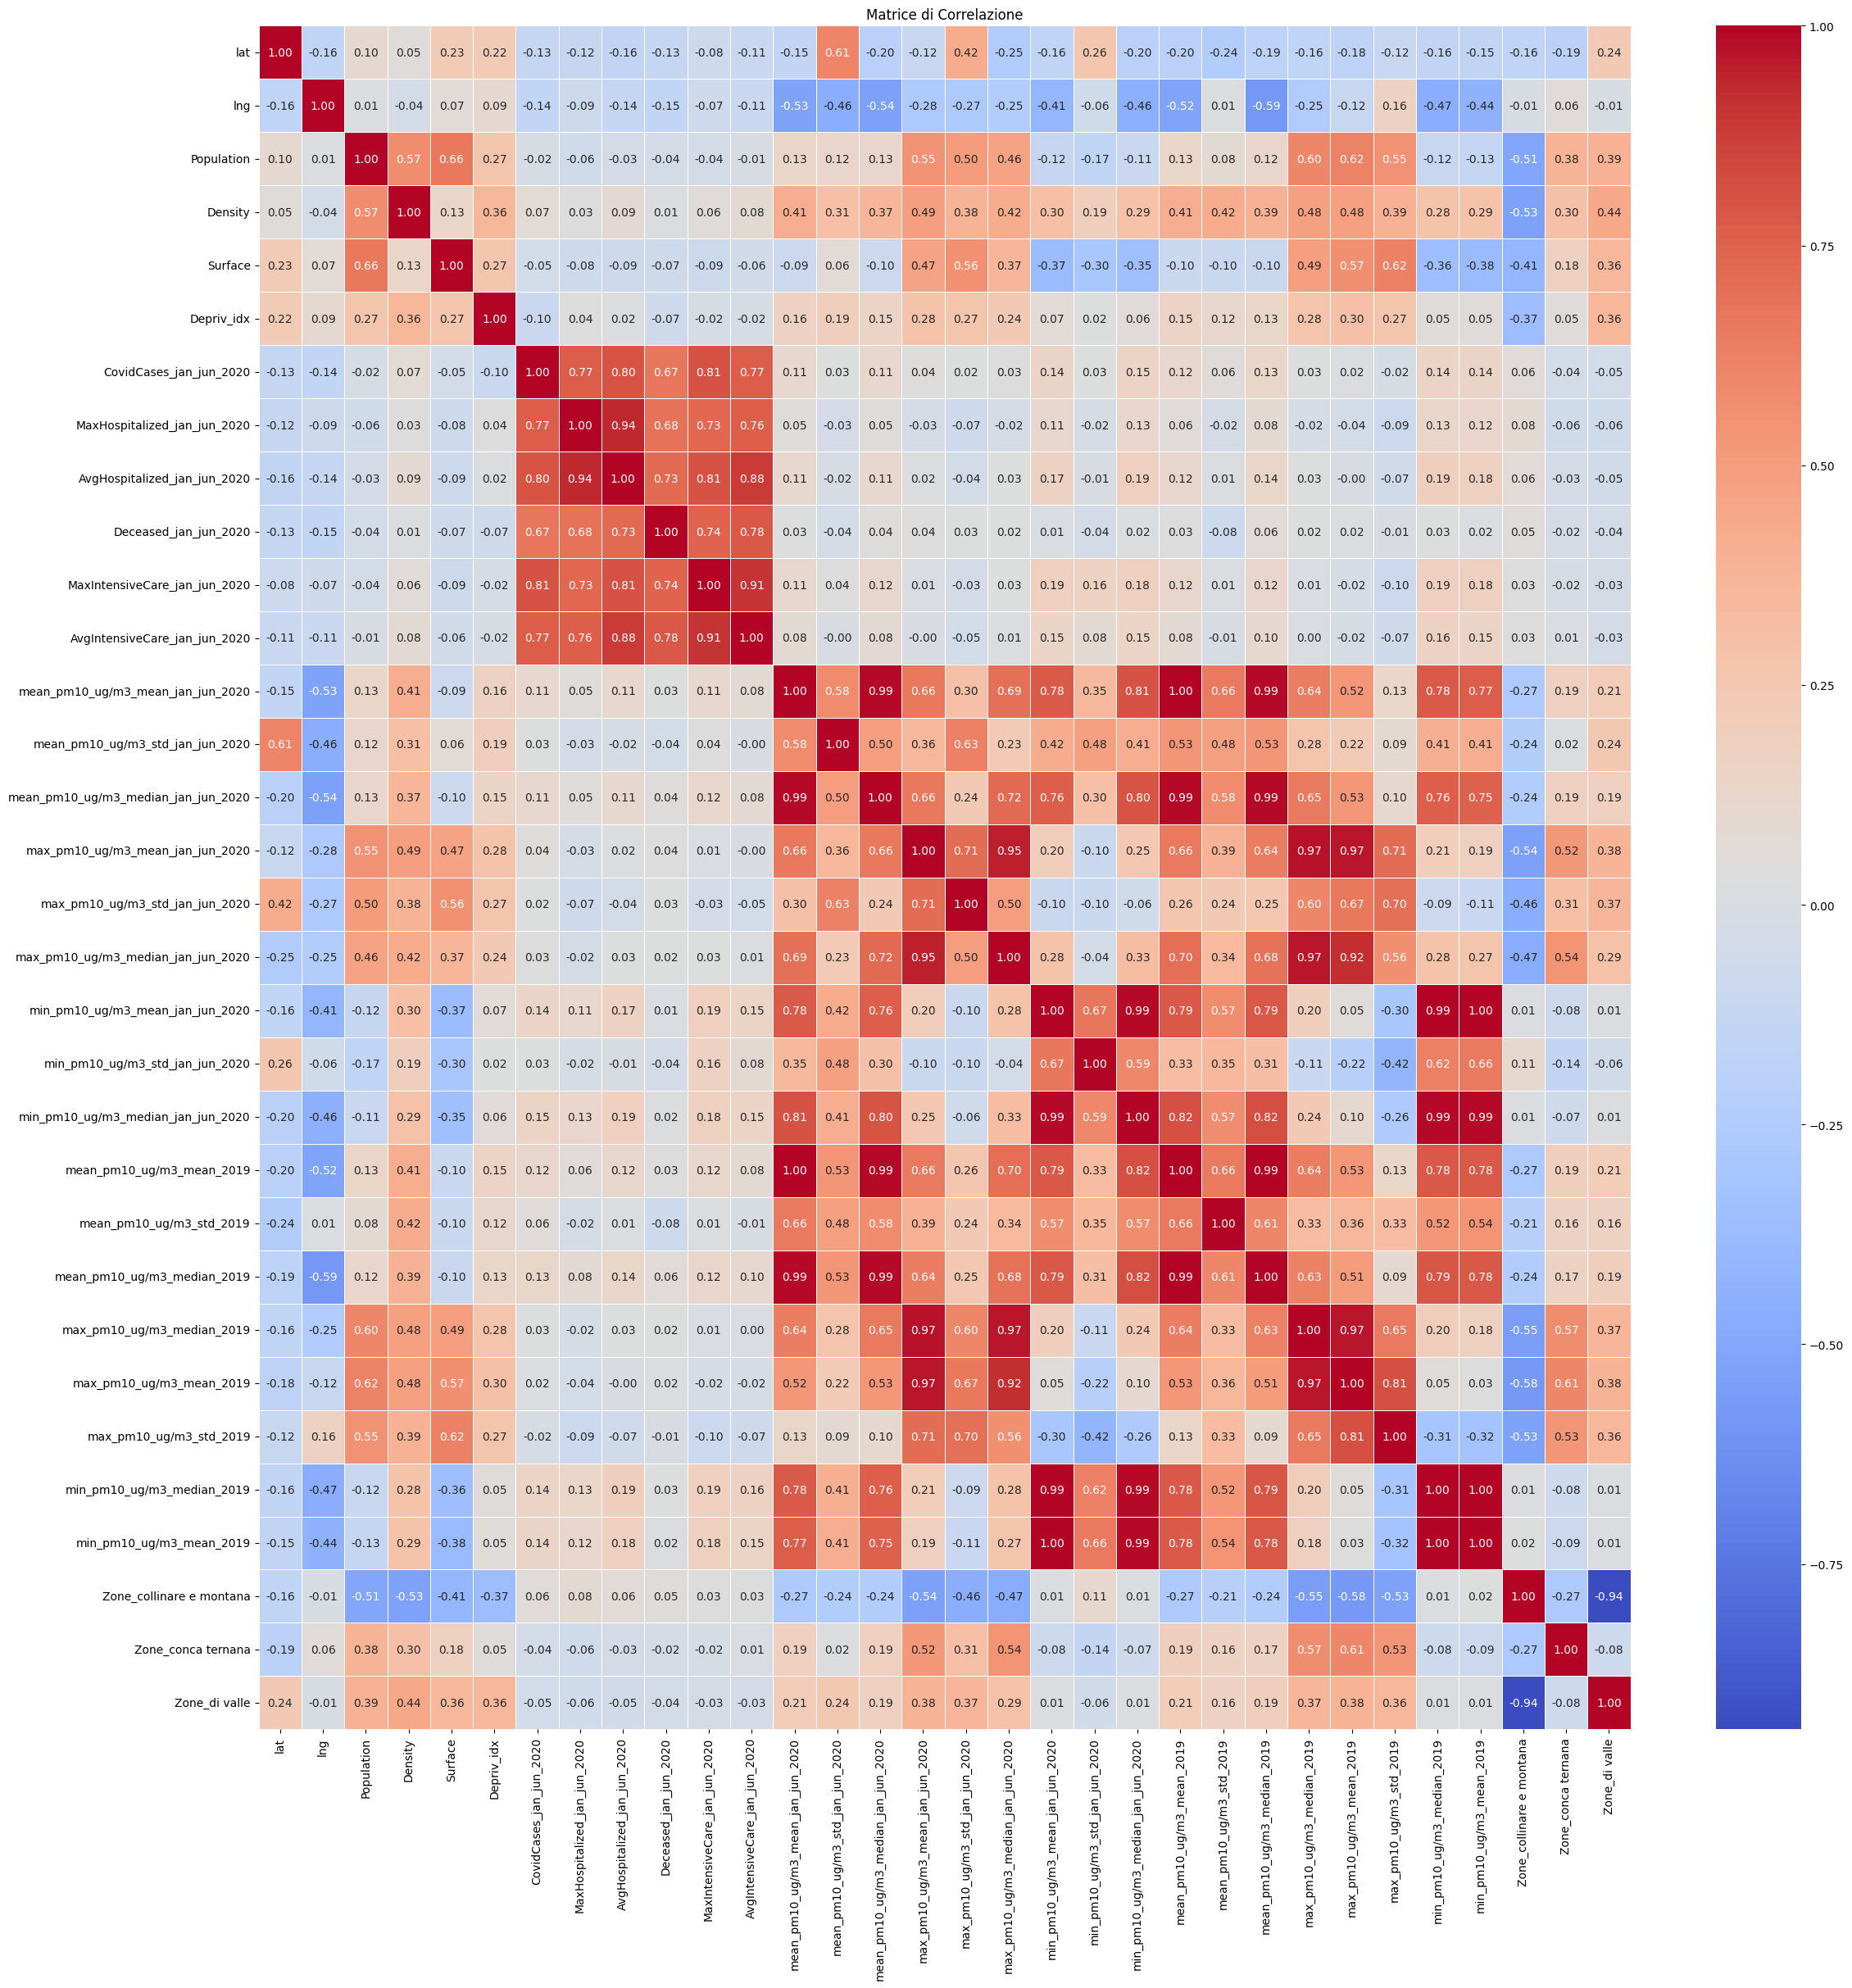

In [13]:
correlation_matrix = cvdata_cleaned.corr() # .corr() metodo della classe DataFrame di Pandas per calcolare la correlazione tra le colonne
plt.figure(figsize=(27, 27)) # Creare una figura (più grande)
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5) # Crea una heatmap con seaborn
plt.title("Matrice di Correlazione")
plt.show()

As expected, it is not possible to find a correlation between the covid data and pollution, in fact the values ​​of the matrix for these intersections are all close to zero (visually softer colors).

However, a correlation (albeit minimal) can be noted between pollution and the valley area with greater impact on the Terni basin (perhaps due to the greater quantity of factories present in the province's soil). On the contrary, a slight negative correlation emerges between the hilly and mountainous areas and the pollution data.
It can be concluded that not discarding these features (zones) still provided useful information.

The values ​​that are most correlated in this case concern precisely the pollution data compared one year later. This may be irrelevant but it clearly demonstrates the validity and reliability of the dataset.
The same also applies to epidemiological data which are closely correlated with each other.

### Map:

Before drawing any map you need to understand the structure of the file found online "limits_R_10_municipalities.geojson":

In [14]:
import geopandas as gpd
import folium # Creazione mappe interattive

# Carichato il file GeoJSON e memorizzato in un GeoDataFrame (gdf)
gdf = gpd.read_file("limits_R_10_municipalities.geojson") 
gdf.columns # Visualizza le colonne del GeoDataFrame per capire com'è strutturato


Index(['name', 'op_id', 'minint_elettorale', 'minint_finloc', 'prov_name',
       'prov_istat_code', 'prov_istat_code_num', 'prov_acr', 'reg_name',
       'reg_istat_code', 'reg_istat_code_num', 'opdm_id', 'com_catasto_code',
       'com_istat_code', 'com_istat_code_num', 'geometry'],
      dtype='object')

In [15]:
for cit in gdf.iloc[:, 0]:  
    print(cit)

Assisi
Bastia Umbra
Bettona
Bevagna
Campello sul Clitunno
Cannara
Cascia
Castel Ritaldi
Castiglione del Lago
Cerreto di Spoleto
Citerna
Città della Pieve
Città di Castello
Collazzone
Corciano
Costacciaro
Deruta
Foligno
Fossato di Vico
Fratta Todina
Giano dell'Umbria
Gualdo Cattaneo
Gualdo Tadino
Gubbio
Lisciano Niccone
Magione
Marsciano
Massa Martana
Monte Castello di Vibio
Montefalco
Monteleone di Spoleto
Monte Santa Maria Tiberina
Montone
Nocera Umbra
Norcia
Paciano
Panicale
Passignano sul Trasimeno
Perugia
Piegaro
Pietralunga
Poggiodomo
Preci
San Giustino
Sant'Anatolia di Narco
Scheggia e Pascelupo
Scheggino
Sellano
Sigillo
Spello
Spoleto
Todi
Torgiano
Trevi
Tuoro sul Trasimeno
Umbertide
Valfabbrica
Vallo di Nera
Valtopina
Acquasparta
Allerona
Alviano
Amelia
Arrone
Attigliano
Baschi
Calvi dell'Umbria
Castel Giorgio
Castel Viscardo
Fabro
Ferentillo
Ficulle
Giove
Guardea
Lugnano in Teverina
Montecastrilli
Montecchio
Montefranco
Montegabbione
Monteleone d'Orvieto
Narni
Orvieto
Otricoli

The names of the Umbrian municipalities have been printed to check whether they differ from those present in the dataframe provided.
Since discrepancies have arisen, you need to format them the same way:

In [16]:
# Recupero del DataFrame pre correlation matrix
cvdata_cleaned = cvdata_cleaned_copy

cvdata_cleaned["City"]=cvdata_cleaned["City"].apply( # Applica una funzione su ogni elemento della colonna City
    lambda x: x.replace( # lambda prende l'elemento e lo assegna a x che poi passa al metodo replace
        "dell_","dell'"
    ).replace(
        "Citta","Città"
    ).replace(
        "Sant_","Sant'"
    ).replace(
        "d_","d'"
    ).replace(
        "_"," "
    )
)

# Verifica che sia avvenuto correttamente (ordina con sort_values i nomi e con reset_index si resetta l'indice ordinato)
cvdata_cleaned["City"].sort_values().reset_index(drop=True).equals(gdf["name"].sort_values().reset_index(drop=True))

True

Now it has been verified that the first column is actually the same as the column in the geopandas dataframe (gds) and consequently the original dataframe has been modified by overwriting the data of the first column (City).
(No problem as we always have the copy anyway).

It was decided to show 3 maps and then draw related qualitative conclusions. The maps, centered on a fairly random coordinate of central Umbria (Collazzone, Province of Pg), show different colors for:
- Density;
- Pollution by fine dust;
- Covid cases.

To add a tooltip, it was necessary to include features such as: 
- Density;
- CovidCases_jan_jun_2020;
- mean_pm10_ug/m3_mean_jan_jun_2020.

With a for loop: iterating through each feature of the GeoJson file, looking for the 'name'.
Once the string present in cvdata_cleaned has been matched, the required variables are added.

In [17]:
# Crea la mappa centrata a Collazzone
mappa_d = folium.Map(location=[42.95, 12.45], zoom_start=8)  

# Crea il choropleth
choropleth = folium.Choropleth(
    geo_data=gdf,  # File con i confini geografici
    name="Choropleth",
    data=cvdata_cleaned,
    columns=['City', 'Density'],  # Colonne: Nome del comune + Dati da visualizzare
    key_on="feature.properties.name",  # Chiave per unire il dataset al GeoJSON (Associa i dati ai confini geografici basandosi sul nome del comune.)
    fill_color="YlOrBr", 
    fill_opacity=0.7,
    line_opacity=0.5,
    legend_name="Densità abitativa",
    highlight=True,
    smooth_factor=0.3
)

# Aggiunge il choropleth alla mappa
choropleth.add_to(mappa_d)

# Lista delle feature da mostrare nel tooltip
tooltip_features = ['City','Density', 'Population', 'Surface']  # Dati da mostrare nel tooltip

# Aggiunge i dati dal dataframe al GeoJSON
for f in choropleth.geojson.data['features']:
    # Troviamo il nome del comune (identificato nella chiave 'name')
    feature_name = f['properties']['name']
    
    # Trova i dati corrispondenti nel dataframe cvdata_cleaned usando 'name' al posto di 'City'
    city_data = cvdata_cleaned[cvdata_cleaned['City'] == feature_name] 
    
    if not city_data.empty: # Assicura che il codice venga eseguito solo se il comune è presente nel DataFrame
        # Aggiunge i dati al GeoJSON per il tooltip
        for tooltip in tooltip_features:
            f['properties'][tooltip] = str(city_data.iloc[0][tooltip])

# Oggetto di Folium che Aggiunge il GeoJsonTooltip alla mappa
folium.GeoJsonTooltip(fields=tooltip_features, aliases=['Città: ','Densità: ', 'Popolazione: ', 'Superficie: ']).add_to(choropleth.geojson)
mappa_d

In [18]:
# Creata la mappa centrata in Umbria
mappa_i = folium.Map(location=[42.95, 12.45], zoom_start=8)  

# Creato il choropleth
choropleth = folium.Choropleth(
    geo_data=gdf,  # File con i confini geografici
    name="Choropleth",
    data=cvdata_cleaned,
    columns=['City', 'mean_pm10_ug/m3_mean_jan_jun_2020'],  # Colonne: Nome del comune + Dati da visualizzare
    key_on="feature.properties.name",  # Chiave per unire il dataset al GeoJSON
    fill_color="YlOrBr", 
    fill_opacity=0.7,
    line_opacity=0.5,
    legend_name="Inquinamento da PM10",
    highlight=True,
    smooth_factor=0.3
)

# Aggiunto il choropleth alla mappa
choropleth.add_to(mappa_i)

# Creazione del tooltip con le informazioni 
tooltip_features = ['City' ,'Density', 'CovidCases_jan_jun_2020', 'mean_pm10_ug/m3_mean_jan_jun_2020']  # Dati da mostrare nel tooltip

# Aggiunge i dati dal dataframe al GeoJSON
for f in choropleth.geojson.data['features']:
    # Troviamo il nome del comune (identificato nella chiave 'name')
    feature_name = f['properties']['name']
    
    # Trova i dati corrispondenti nel dataframe cvdata_cleaned
    city_data = cvdata_cleaned[cvdata_cleaned['City'] == feature_name]
    
    if not city_data.empty:
        # Aggiunge i dati al GeoJSON 'properties' per ogni comune
        for tooltip in tooltip_features:
            value = city_data.iloc[0][tooltip]
            f['properties'][tooltip] = str(city_data.iloc[0][tooltip])

# Aggiunge il GeoJsonTooltip alla mappa, utilizzando i dati nelle proprietà
folium.GeoJsonTooltip(fields=tooltip_features, aliases= ['Città: ', 'Densità: ', 'Casi covid per 1000 abitanti: ', 'Inquinamento da PM10: ']).add_to(choropleth.geojson)

# Mostra la mappa
mappa_i

In [19]:
# Creata la mappa centrata in Umbria
mappa_cv = folium.Map(location=[42.95, 12.45], zoom_start=8)  

# Creato il choropleth
choropleth = folium.Choropleth(
    geo_data=gdf,  # File con i confini geografici
    name="Choropleth",
    data=cvdata_cleaned,
    columns=['City', 'CovidCases_jan_jun_2020'],  # Colonne: Nome del comune + Dati da visualizzare
    key_on="feature.properties.name",  # Chiave per unire il dataset al GeoJSON 
    fill_color="YlOrRd",
    fill_opacity=0.7,
    line_opacity=0.5,
    legend_name="Casi covid",
    highlight=True,
    smooth_factor=0.3
)

# Aggiunto il choropleth alla mappa
choropleth.add_to(mappa_cv)

# Creazione del tooltip con le informazioni
tooltip_features = ['City' ,'CovidCases_jan_jun_2020', 'AvgHospitalized_jan_jun_2020', 'AvgIntensiveCare_jan_jun_2020']  # Dati da mostrare nel tooltip

# Aggiunge i dati dal dataframe al GeoJSON
for f in choropleth.geojson.data['features']:
    # Troviamo il nome del comune (identificato nella chiave 'name')
    feature_name = f['properties']['name']
    
    # Trova i dati corrispondenti nel dataframe cvdata_cleaned
    city_data = cvdata_cleaned[cvdata_cleaned['City'] == feature_name]
    
    if not city_data.empty:
        # Aggiunge i dati al GeoJSON 'properties' per ogni comune
        for tooltip in tooltip_features:
            f['properties'][tooltip] = str(city_data.iloc[0][tooltip])

# Aggiunge il GeoJsonTooltip alla mappa, utilizzando i dati nelle proprietà
folium.GeoJsonTooltip(fields=tooltip_features, aliases= ['Città: ', 'Casi covid per 1000 abitanti: ', 'Media ricoveri per 1000 abitanti: ', 'Media terapie intensive per 1000 abitanti: ']).add_to(choropleth.geojson)

# Mostra la mappa
mappa_cv

Qualitatively, no relationship can be observed between covid cases and pollution or between covid cases and density.
A slight dependence between density and pollution may appear except for the municipalities of Narni and Orticoli where the density is low but pollution is relatively high.
It could be indicative of the presence of factories but no data has been found in this regard.
Furthermore, pollution is significantly lower in the areas of the Umbria-Marche Apennines.

## Modelling:

### Unsupervised Learning

In unsupervised learning, only a set of features measured on different samples is available. In the case in question it is useful for further pre-processing and then moving on to a supervised model.

#### Clustering:

Clustering is an unsupervised learning technique used to identify groups of data with similar characteristics within a dataset. The K-means algorithm is one of the most popular clustering methods based on iterative descent. It is used when all the variables are quantitative, which divides the data into K clusters trying to maximize the intra-cluster similarity and the separation between different clusters.

1. Choice of the number of clusters (K) and random initialization of K points in the dataset, called centroids (K in the case in question varies in the interval [2,18]);
2. Each point in the dataset is assigned to the closest centroid cluster, calculating the Euclidean distance between the points in the feature space;
3. Recalculation of the centroids: for each cluster the position of the centroid is updated as the average of the points assigned to the cluster;
4. Steps 2 and 3 are iterated in order to verify the convergence condition, i.e. when the centroids no longer move or the changes become negligible.

K-Means optimization is based on the minimization of inertia, i.e. the sum of the quadratic distances between each point and its centroid described by:

$$ W(C)=\sum_{i=1}^{k} \sum_{x \in C_i} ||x - \mu_i||^2$$

Where $\mu_i$ = centroid of cluster $C_i$

It should be interpreted as a measure of the dispersion (scatter) of the data within the cluster. In fact, the smaller its value, the smaller the distances of the data from the chosen centroid, and consequently, the less dispersed.  
Its tendency is trivially to decrease as K increases, since "smaller" clusters will be created, which implies less data and less dispersion within them. It is necessary to note the contraindication: a high number of clusters increases the difficulty of interpreting the results and the risk of overfitting. In conclusion, it is up to the programmer to evaluate which is the right solution taking into account K and the value of inertia.

There are various methods to decide the optimal number of Clusters (K), in this case they will be taken into consideration:
- Elbow Method: qualitative method that observes the trend of the inertia curve as K varies. The point at which the curve changes the trend (significant decrease in inertia) in the shape of an "elbow" is chosen, hence the name.
- Calinski-Harabasz index: method that evaluates the quality of the process thanks to the ratio between the dispersion between clusters (matrix between $B_k$) and that in the claster itself (matrix within $W_k$), maximizing the CH index:

$$CH(k) = \frac{tr(B_k)}{Tr(W_k)} \frac{N-k}{k-1}$$

- N= number of observations;
- k= number of clusters.

#### Preprocessing:
It is necessary to scale the features making them of the same weight. Mainly the reason is that being a method based on Euclidean distances, the outliers weigh too much. To this end, sklearn uses the StandardScaler method.

In [20]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import calinski_harabasz_score

#Giusto un controllo
cvdata_cleaned=cvdata_cleaned_copy
cvdata_cleaned.head()

,City,lat,lng,Population,Density,Surface,Depriv_idx,CovidCases_jan_jun_2020,MaxHospitalized_jan_jun_2020,AvgHospitalized_jan_jun_2020,...,min_pm10_ug/m3_median_jan_jun_2020,mean_pm10_ug/m3_mean_2019,mean_pm10_ug/m3_std_2019,mean_pm10_ug/m3_median_2019,max_pm10_ug/m3_median_2019,max_pm10_ug/m3_mean_2019,max_pm10_ug/m3_std_2019,min_pm10_ug/m3_median_2019,min_pm10_ug/m3_mean_2019,Zone
0,Acquasparta,42.691173,12.546451,4611,57.0,81.61,1.013507,1.301236,0.216873,0.059333,...,0.433291,0.474132,0.127640,0.492131,0.342349,0.315504,0.183207,0.474027,0.456042,collinare e montana
1,Allerona,42.812033,11.973053,1722,21.0,82.61,-1.309272,1.742160,0.580720,0.195549,...,0.262766,0.441134,0.036301,0.498647,0.303011,0.276595,0.280433,0.275532,0.255519,collinare e montana
2,Alviano,42.588208,12.295936,1428,60.0,23.90,-2.148882,1.400560,0.700280,0.176913,...,0.683500,0.878277,0.719832,0.908141,0.416703,0.391727,0.253816,0.695757,0.685467,collinare e montana
3,Amelia,42.553528,12.416776,11852,89.0,132.50,-0.832084,0.421870,0.084374,0.026773,...,0.528906,0.614523,0.296386,0.662854,0.450392,0.432760,0.323420,0.508475,0.498289,collinare e montana
4,Arrone,42.583433,12.769865,2703,66.0,41.04,-0.479919,2.589715,0.369959,0.176000,...,0.166819,0.298950,0.174518,0.300069,0.299299,0.322116,0.364649,0.192653,0.178480,collinare e montana


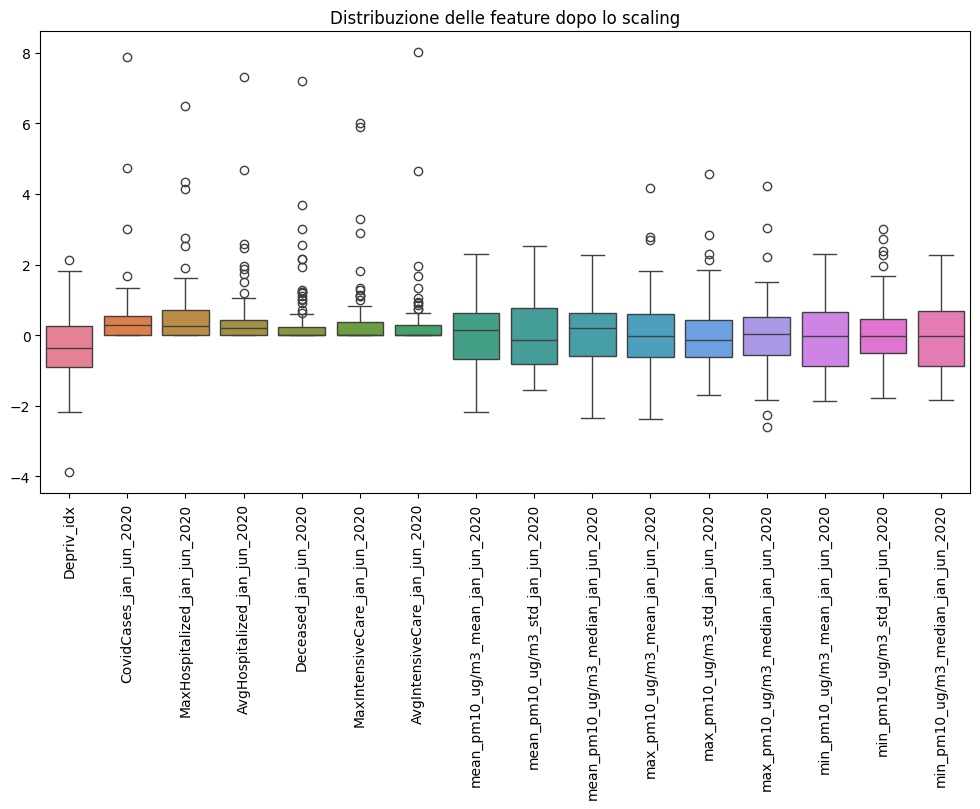

In [21]:
# Scalo di dati delle colonne che mi interessano in modo differente se si tratta di conteggi o altre quantità (inq)
cvdata_k=cvdata_cleaned.iloc[:,6:22]
cont_k=cvdata_k.iloc[:,:7]
other_k=cvdata_k.iloc[:,7:]
scaler_cont = StandardScaler(with_mean=False) # StandardScaler serve per avere dati con media 0 e dev standard 1. with_mean=False serve per non avere media 0
scaler_other = StandardScaler()

#Processo di scaling
cont_scal = scaler_cont.fit_transform(cont_k) # fit calcola sigma e mu
other_scal = scaler_other.fit_transform(other_k)
cvdata_kscal = pd.DataFrame(cont_scal, index=cvdata_k.index, columns=cont_k.columns).join(pd.DataFrame(other_scal, index=cvdata_k.index, columns=other_k.columns))

# Visualizzazione del risultato che mi sottolinea più il problema oulier è il boxplot:
plt.figure(figsize=(12, 6))
sns.boxplot(data=cvdata_kscal)
plt.xticks(rotation=90)  # Ruota i nomi delle feature se sono molte
plt.title("Distribuzione delle feature dopo lo scaling")
plt.show()


The use of StandardScaler(with_mean=False) is used on the count variables, in fact here it is not useful to center the data around zero (always positive).

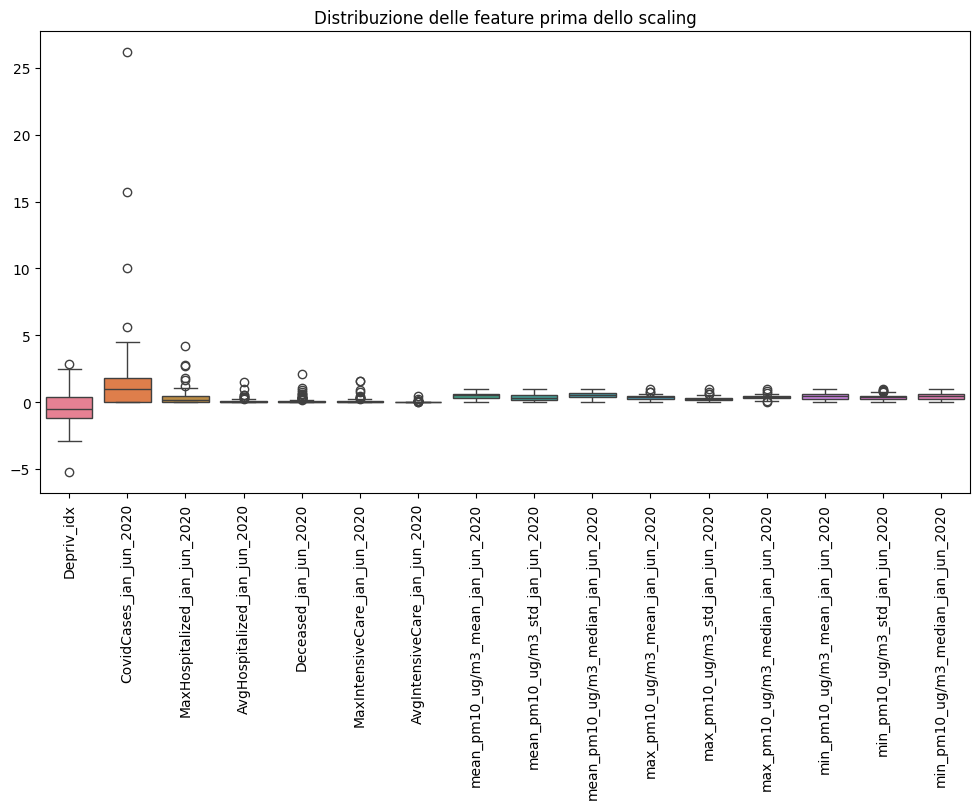

In [22]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=cvdata_k)
plt.xticks(rotation=90)  # Ruota i nomi delle feature se sono molte
plt.title("Distribuzione delle feature prima dello scaling")
plt.show()

The difference with non-scaled features is clear:
It should be underlined that the use of the box-plot visualization is not a random choice but was evaluated as it is the one that best highlights the distribution and outliers.

A function is defined that applies K-Means on the dataset scaled by the required K values.
Required parameters:
- DataFrame with scaled features;
- list with the values ​​of k to test;
- evaluate_CH: if True, calculate the Calinski-Harabasz index to find the optimal k

Return:
- DataFrame with cluster assignments for each value of k;
- Inertia graph (useful for the elbow method).

So thanks to this it is possible to estimate the best number of Clusters with the "elbow" method, certainly and if it is considered necessary also with Calinski-Harabasz.

 Numero ottimale di cluster secondo Calinski-Harabasz: 3 (Valore CH: 36.50)


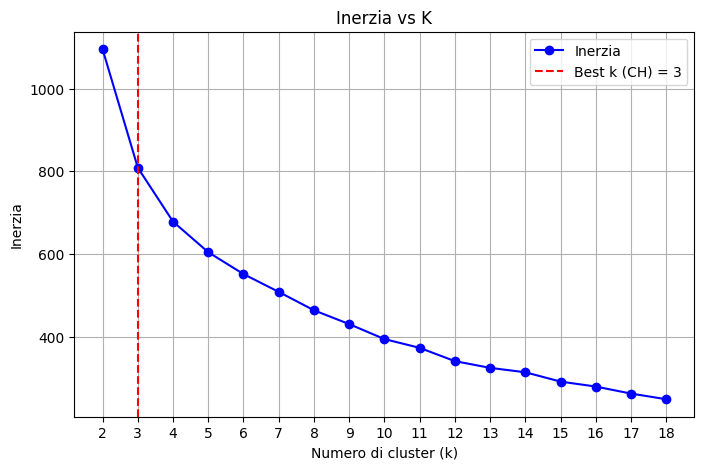

In [23]:
def function_k(cvdata_kscal, k_values, evaluate_CH=True):
    # liste e dizionario che conterrà assegnamenti ai cluster
    inertia_values = []
    calinski_harabasz_scores = [] if evaluate_CH else None
    
    cluster_results = {}

    for k in k_values:
        # Applica KMeans con il numero di cluster k (seme fisso)
        kmeans = KMeans(n_clusters=k, n_init=20, random_state=42) # 20= # volte in cui viene eseguito con =/ init per mitigare problema della inizializzazione
        labels = kmeans.fit_predict(cvdata_kscal) #calcola centroidi, restituisce lables assegna ogni pto ad un centroide
        
        # Salvataggio risultati 
        cluster_results[f"{k}_clusters"] = labels # etichette assegnate ai cluster
        inertia_values.append(kmeans.inertia_)
        if evaluate_CH:
            calinski_harabasz_scores.append(calinski_harabasz_score(cvdata_kscal, labels))

    # Converte il dizionario cluster_result in un DataFrame con le assegnazioni ai cluster per ogni valore di k
    df_clusters = pd.DataFrame(cluster_results, index=cvdata_kscal.index)

    # Trova il miglior k secondo il criterio di Calinski-Harabasz
    if evaluate_CH:
        best_k_CH = k_values[np.argmax(calinski_harabasz_scores)] # Trova l'indice del val max CH e recupera val k corr.
        print(f" Numero ottimale di cluster secondo Calinski-Harabasz: {best_k_CH} "
              f"(Valore CH: {max(calinski_harabasz_scores):.2f})")

    # Grafico
    plt.figure(figsize=(8, 5))
    plt.plot(k_values, inertia_values, marker="o", linestyle="-", color="b", label="Inerzia")
    plt.xlabel("Numero di cluster (k)")
    plt.ylabel("Inerzia")
    plt.title("Inerzia vs K")
    plt.xticks(k_values)
    
    # Evidenzia il miglior k se il CH è attivo
    if evaluate_CH:
        plt.axvline(best_k_CH, color='r', linestyle='--', label=f"Best k (CH) = {best_k_CH}")

    plt.legend()
    plt.grid(True)
    plt.show()

    return df_clusters

df_clusters = function_k(cvdata_kscal, k_values=range(2, 19), evaluate_CH=True)


Therefore, evaluating the graph qualitatively and considering the CH method, it is very solid to state that from k=3 the decrease in inertia stabilizes and begins to decrease in a less abrupt manner.
Now it was deemed sensible to understand what data is resolved in these 3 clusters.

It was considered appropriate to use violin plots in order to visualize the values ​​of the 3 Clusters according to the features. The decision fell on this type of graphs as they are able to summarize, and consequently provide, more information than others (box plots for example).
In fact, for each cluster the data distribution is shown where the width indicates the density of the data present in the specific region and includes the statistics of the box plot.
Thanks to these, it is therefore possible to evaluate the distribution of the variables between the 3 clusters, understand if they are distinct and identify patterns.

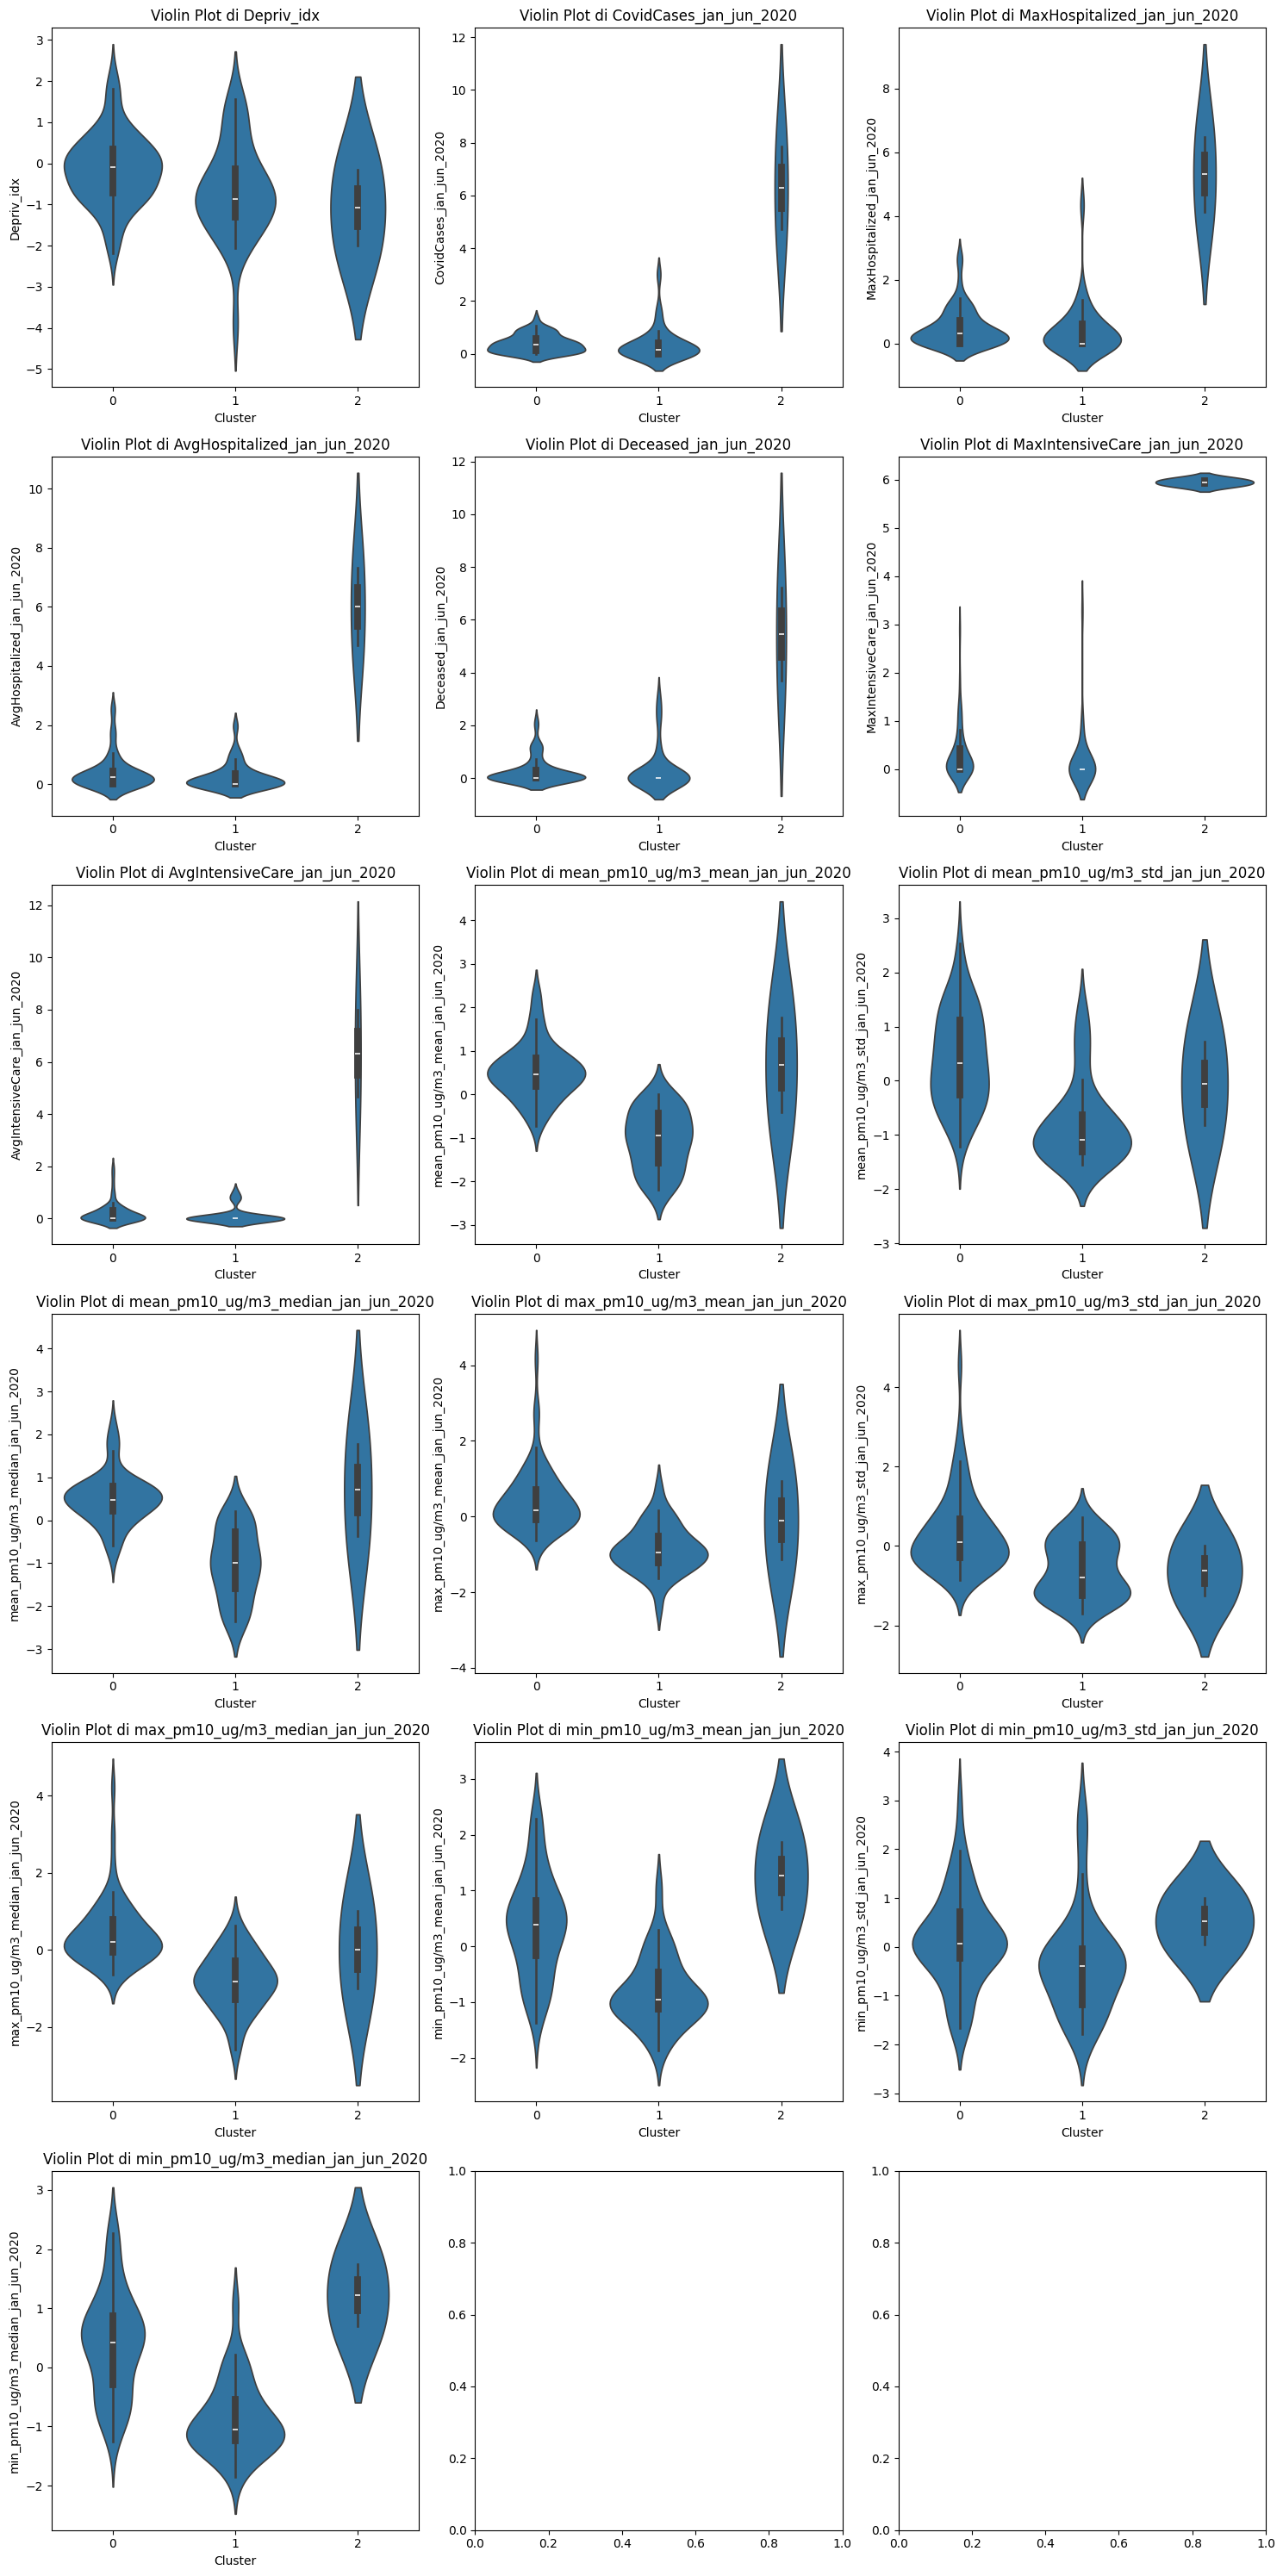

In [24]:
# Crea una copia temporanea con i cluster
cvdata_temp = cvdata_kscal.copy()
cvdata_temp['Cluster'] = df_clusters["3_clusters"] # Aggiunge una colonna 'Clusters' al DataFrame temporaneo dalla colonna '3_clusters'

# Numero di features
num_features = len(cvdata_kscal.columns) # num features=num subplots
num_cols = 3  # Numero di colonne nei subplot (3 grafici per ogni riga)
num_rows = int(np.ceil(num_features / num_cols))  # Calcola il numero di righe necessario per tutti i grafici (arrotonda per eccesso ceil)

# Crea la figura con subplot
fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, 5 * num_rows))
axes = axes.flatten()  # Rende la griglia di subplot un array 1D (accedi ai subplots con 1 solo indice)

# Disegna i violin plot per ogni feature con l'indice i
for i, feature in enumerate(cvdata_kscal.columns):
    sns.violinplot(x='Cluster', y=feature, data=cvdata_temp, ax=axes[i]) # Violin plot per ogni feature
    axes[i].set_title(f'Violin Plot di {feature}')


plt.tight_layout()
plt.show()

In the case under examination, for some features it is possible to notice more separate clusters implying the significance of this process (epidemiological features).

The features relating to PM10 values ​​instead show more overlap between the clusters.

Furthermore, we note how some have more heterogeneous distributions for some features (Cluster 2 x features [1:7] => regions with disparate situations) while in other cases we notice homogenous distributions (Cluster 0, 1 x same features).

In general, for some variables, Clusters 0 and 1 seem to have characteristics in common, while Cluster 2 has very different distributions (the difference highlighted above all in the epidemiological parameters).

The graphs have now been projected onto the map, unlike before the position is taken into account with the average of the lat and lng values ​​as expressively requested.

In [25]:
# Prima è necessario unire i due dataset
cvdata_cluster = pd.concat([cvdata_cleaned.iloc[:,:6],cvdata_temp,cvdata_cleaned.iloc[:,22:]], axis=1)
print(cvdata_cluster.columns)

Index(['City', 'lat', 'lng', 'Population', 'Density', 'Surface', 'Depriv_idx',
       'CovidCases_jan_jun_2020', 'MaxHospitalized_jan_jun_2020',
       'AvgHospitalized_jan_jun_2020', 'Deceased_jan_jun_2020',
       'MaxIntensiveCare_jan_jun_2020', 'AvgIntensiveCare_jan_jun_2020',
       'mean_pm10_ug/m3_mean_jan_jun_2020', 'mean_pm10_ug/m3_std_jan_jun_2020',
       'mean_pm10_ug/m3_median_jan_jun_2020',
       'max_pm10_ug/m3_mean_jan_jun_2020', 'max_pm10_ug/m3_std_jan_jun_2020',
       'max_pm10_ug/m3_median_jan_jun_2020',
       'min_pm10_ug/m3_mean_jan_jun_2020', 'min_pm10_ug/m3_std_jan_jun_2020',
       'min_pm10_ug/m3_median_jan_jun_2020', 'Cluster',
       'mean_pm10_ug/m3_mean_2019', 'mean_pm10_ug/m3_std_2019',
       'mean_pm10_ug/m3_median_2019', 'max_pm10_ug/m3_median_2019',
       'max_pm10_ug/m3_mean_2019', 'max_pm10_ug/m3_std_2019',
       'min_pm10_ug/m3_median_2019', 'min_pm10_ug/m3_mean_2019', 'Zone'],
      dtype='object')


In [26]:
# Creata la mappa centrata in Umbria
mappa_c = folium.Map(location=[cvdata_cluster['lat'].mean(), cvdata_cluster['lng'].mean()], zoom_start=8)  

# Creato il choropleth
choropleth = folium.Choropleth(
    geo_data=gdf,  # File con i confini geografici
    name="Choropleth",
    data=cvdata_cluster,
    columns=['City', 'Cluster'],  # Colonne: Nome del comune + Dati da visualizzare
    key_on="feature.properties.name",  # Chiave per unire il dataset al GeoJSON 
    fill_color="PuBuGn",
    fill_opacity=0.7,
    line_opacity=0.5,
    legend_name="Cluster Map",
    highlight=True,
    smooth_factor=0.3
)

# Aggiunto il choropleth alla mappa
choropleth.add_to(mappa_c)

# Creazione del tooltip con le informazioni
tooltip_features = ['City' ,'Zone']  # Dati da mostrare nel tooltip

# Aggiunge i dati dal dataframe al GeoJSON
for f in choropleth.geojson.data['features']:
    # Trova il nome del comune (identificato nella chiave 'name')
    feature_name = f['properties']['name']
    
    # Trova i dati corrispondenti nel dataframe
    city_data = cvdata_cluster[cvdata_cluster['City'] == feature_name]
    
    if not city_data.empty:
        # Aggiunge i dati al GeoJSON 'properties' per ogni comune
        for tooltip in tooltip_features:
            f['properties'][tooltip] = str(city_data.iloc[0][tooltip])

# Aggiunge il GeoJsonTooltip alla mappa, utilizzando i dati nelle proprietà
folium.GeoJsonTooltip(fields=tooltip_features, aliases= ['Città: ', 'Zona: ']).add_to(choropleth.geojson)

mappa_c

The third cluster (Cluster 2) can be seen from the map which is made up of only two municipalities: Porano and Giove.
This once again underlines the anomaly of these two municipalities, especially in the epidemiological data, reinforcing the previously explained hypotheses. To this end, a 3D scatter plot will be created as a final analysis.

#### Clustering with PCA:

Clustering with PCA (Principal Component Analysis) is a technique that combines the two approaches:
- Clustering: as with K-Means, groups data into similar sets;
- PCA: technique that reduces the dimensionality of the data, eliminating collinearity but preserving as much variance as possible in the original data.

In particular, it takes a general dataset provided with _n_ features, then combines them linearly to create new ones: PC1, PC2, ...
$$ PC_i = \phi_{i1}

Where the _X_ are the original features and the $\phi$ are the weights calculated by the PCA (loading).

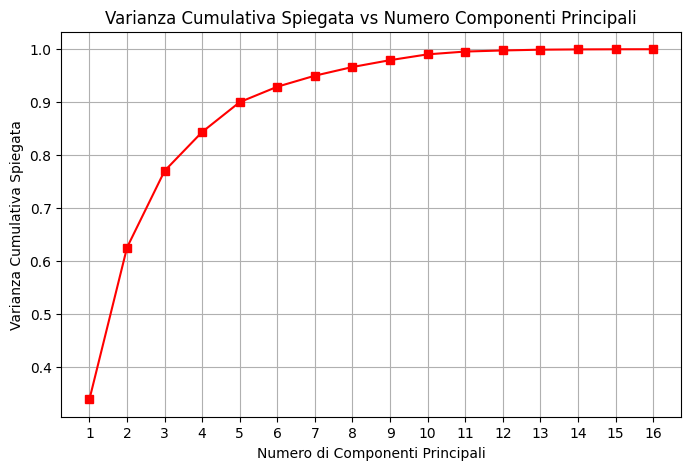

In [27]:
from sklearn.decomposition import PCA

pca=PCA() 
# Calcolo matrice della covarianza
X_pca=pca.fit_transform(cvdata_kscal) #dati trasformati (score matrix)

# La score matrix è la matrice con dati proiettati nello spazio delle componenti principali
# Ha dimensioni: (n. osservazioni) x (n. componenti principali)

varianza_spiegata = pca.explained_variance_ratio_  # Restituisce un array con la percentuale di varianza spiegata da ciascuna componente principale

# Calcolare la varianza cumulativa (somma progressiva delle varianze spiegate)
varianza_cumulativa = np.cumsum(varianza_spiegata)

# Creare l'asse x con il numero di componenti principali (+1 per tutti i valori di pca sennò arange non include l'ultimo valore)
x = np.arange(1, pca.n_components_ + 1)

# Plot della varianza cumulativa spiegata
plt.figure(figsize=(8, 5))
plt.plot(x, varianza_cumulativa, '-s', color='r')
plt.title("Varianza Cumulativa Spiegata vs Numero Componenti Principali")
plt.xlabel("Numero di Componenti Principali")
plt.ylabel("Varianza Cumulativa Spiegata")
plt.xticks(x)
plt.grid(True)


Still considering the "elbow" method valid, it is considered a good compromise to choose the number of PCs=3.

In [28]:
print(f"Varianza cumulativa con 3 PC: {varianza_cumulativa[2]:.2f}")

Varianza cumulativa con 3 PC: 0.77


This is because a 3-dimensional graph is easily readable and can explain 77% of the variance in the data; acceptable result.

 It is very useful to visualize how the new features (PC1, PC2 and PC3) depend on the starting ones, or rather how the original features influence the PCi.
 To this end, 3 loading bar plots are constructed:

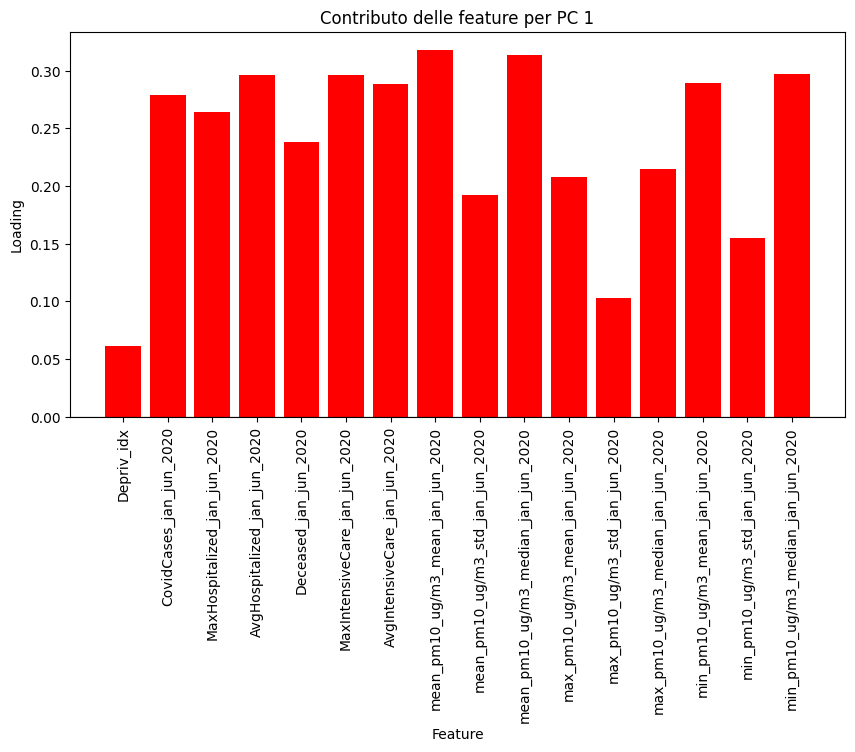

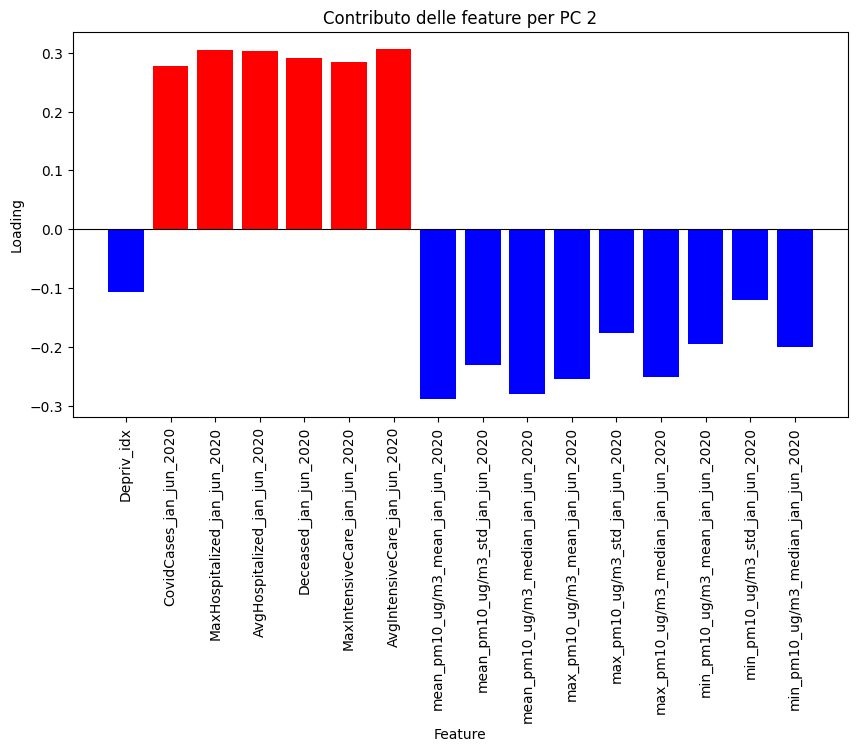

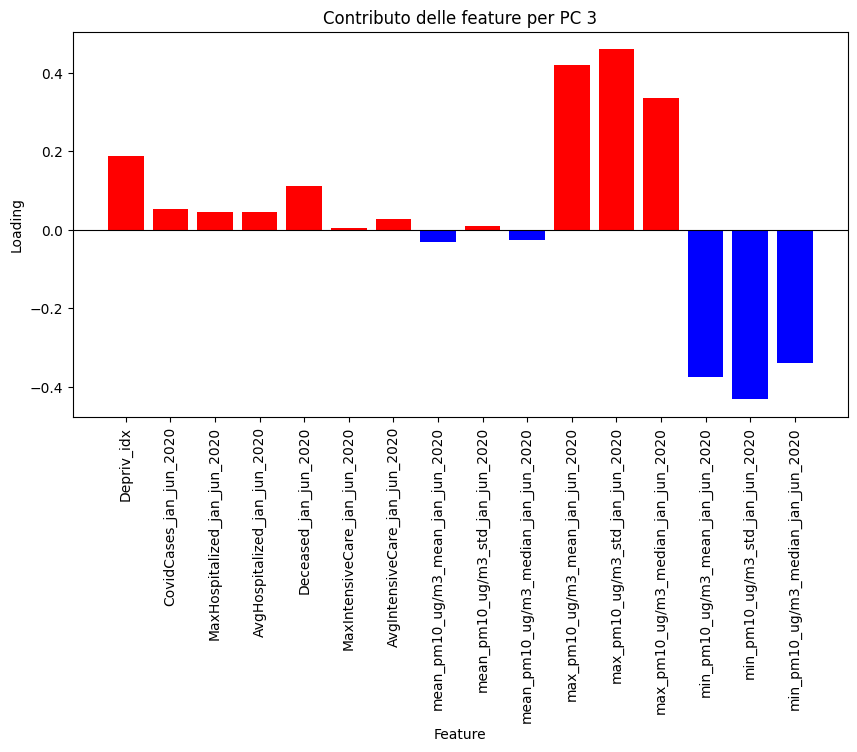

In [29]:
components = pca.components_[:3]  # Prendiamo solo i loading delle prime 3 PC
features = cvdata_kscal.columns

for i in range(3):  # Loop sulle 3 PC
    plt.figure(figsize=(10, 5))
     # Usa una mappa di colori che riflette il valore del loading
    colors = ["red" if v > 0 else "blue" for v in components[i]]
    plt.bar(features, components[i], color=colors)
    plt.axhline(0, color='black', linewidth=0.8)
    plt.xticks(rotation=90)
    plt.title(f"Contributo delle feature per PC {i+1}")
    plt.xlabel("Feature")
    plt.ylabel("Loading")
    plt.show()

It stands out that PC1, by definition the most important (largest explained variance), is highly dependent on almost all features. The second main component, however, receives positive contributions from epidemiological features, negative contributions from those relating to pollution. The PC3 is extremely less dependent on the starting features, in fact many of the Loadings are almost zero. The only relevant contributions are those deriving from the min\max of the mean, median and standard deviation of the pollution.

Let's repeat the clustering:

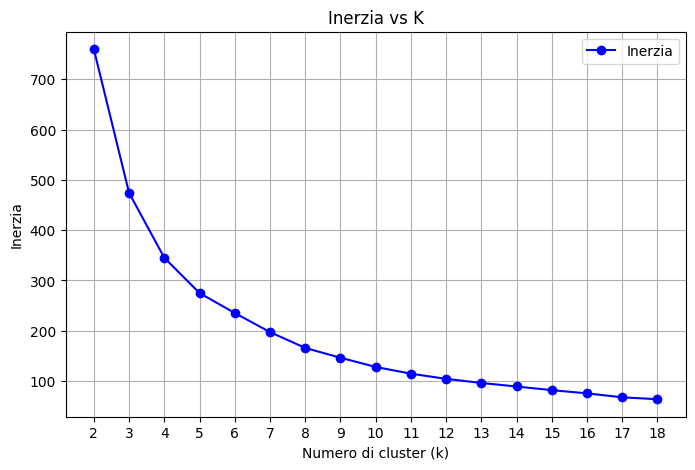

In [30]:
# Esegue PCA per ridurre il set di dati a 3 componenti principali
pc3 = PCA(n_components=3)
pca_data = pc3.fit_transform(cvdata_kscal)  # Trasforma i dati in 3 componenti principali

cvdata_scalpc_df = pd.DataFrame(pca_data) # Dati convertiti in Dataframe
# Rinomina le colonne del DataFrame con i risultati della PCA
cvdata_scalpc_df.columns = ['pc1', 'pc2', 'pc3']
# Richiama la funzione "function_k" che crea un grafico inerzia vs numero cluster e crea un nuovo DataFrame con i cluster assegnati
df_clusters_pc = function_k(cvdata_scalpc_df, k_values=range(2, 19), evaluate_CH=False)

Inertia has decreased => for clustering the PCA method (3) is more efficient in this case. It turns out that the most suitable number of clusters is 4 (elbow method).

In [31]:
df_clusters_pc.head()

,2_clusters,3_clusters,4_clusters,5_clusters,6_clusters,7_clusters,8_clusters,9_clusters,10_clusters,11_clusters,12_clusters,13_clusters,14_clusters,15_clusters,16_clusters,17_clusters,18_clusters
0,0,2,2,4,0,2,3,8,9,1,3,12,10,12,5,3,13
1,0,0,3,3,0,2,0,5,9,1,3,12,13,12,0,14,1
2,0,2,2,0,3,5,6,0,4,10,9,4,3,4,1,0,15
3,0,2,2,4,3,0,6,0,4,9,1,9,10,1,5,11,7
4,0,0,1,1,0,2,0,5,9,1,11,12,13,5,0,14,1


In [32]:
cvdata_cluster_pc = pd.concat([cvdata_cleaned, df_clusters_pc, cvdata_scalpc_df], axis=1)
print(cvdata_cluster_pc.columns)

Index(['City', 'lat', 'lng', 'Population', 'Density', 'Surface', 'Depriv_idx',
       'CovidCases_jan_jun_2020', 'MaxHospitalized_jan_jun_2020',
       'AvgHospitalized_jan_jun_2020', 'Deceased_jan_jun_2020',
       'MaxIntensiveCare_jan_jun_2020', 'AvgIntensiveCare_jan_jun_2020',
       'mean_pm10_ug/m3_mean_jan_jun_2020', 'mean_pm10_ug/m3_std_jan_jun_2020',
       'mean_pm10_ug/m3_median_jan_jun_2020',
       'max_pm10_ug/m3_mean_jan_jun_2020', 'max_pm10_ug/m3_std_jan_jun_2020',
       'max_pm10_ug/m3_median_jan_jun_2020',
       'min_pm10_ug/m3_mean_jan_jun_2020', 'min_pm10_ug/m3_std_jan_jun_2020',
       'min_pm10_ug/m3_median_jan_jun_2020', 'mean_pm10_ug/m3_mean_2019',
       'mean_pm10_ug/m3_std_2019', 'mean_pm10_ug/m3_median_2019',
       'max_pm10_ug/m3_median_2019', 'max_pm10_ug/m3_mean_2019',
       'max_pm10_ug/m3_std_2019', 'min_pm10_ug/m3_median_2019',
       'min_pm10_ug/m3_mean_2019', 'Zone', '2_clusters', '3_clusters',
       '4_clusters', '5_clusters', '6_clusters', '7

Now, as requested, a 3D graph will be displayed (since the chosen number of principal components is 3), which will show the data divided into 4 clusters (the number of these has been evaluated as explained above).

To this end, the hypothesis of a scatter graph was evaluated, so that the shape and color of the data can clearly separate them.

In [33]:
def build_3d_scatter_plot(df, x_col, y_col, z_col, cluster_col, hover_col, title='Scatter Plot 3D', **kwargs): # **kwargs: Argomenti opzionali per passare configurazioni aggiuntive a Plotly
    def scatter_3d_updater():
        fig = px.scatter_3d(df, 
                            x=x_col,  
                            y=y_col,  
                            z=z_col,  
                            color=cluster_col,  
                            symbol=cluster_col,  
                            hover_name=hover_col,  
                            **kwargs)
        
        fig.update_traces(marker=dict(size=5), showlegend=False)

        fig.update_layout(
            title=title,
            scene=dict(
                xaxis_title=x_col,  
                yaxis_title=y_col,
                zaxis_title=z_col
            ),
            margin=dict(l=0, r=0, b=0, t=40)
        )
        
        fig.show()
    
    return scatter_3d_updater

# Esegue la funzione x lo scatter 3D di 3 componenti principali con i cluster assegnati
scatter_3d_plot = build_3d_scatter_plot(
    df=cvdata_cluster_pc, 
    x_col='pc1',  
    y_col='pc2',  
    z_col='pc3',  
    cluster_col='4_clusters',  
    hover_col='City',  
    title='3D Scatter Plot of PCA Components with Clusters'
)

scatter_3d_plot()



Again, clear evidence of how the two municipalities of Giove and Porano evidently separate themselves also in the PCi space.

### Supervised Learning

#### Linear regression

Supervised Learning is a statistical learning technique in which the model trains with a specific set (training set) in order to predict data not yet used for training purposes (test set).

In this case we will use two methods to carry out a regression in order to predict the relationship between:
- Covid cases;
- Population.

While as input the columns relating to: lat, lng, surface, the average value expressed in μg/m3 of the daily average of pm10 detected in the period Jan-June 2020, the average value expressed in μg/m3 of the daily standard deviation of pm10 detected in the period Jan-June 2020 and the average value expressed in μg/m3 of the daily median of pm10 detected in the period Jan-June 2020 will be used.

To this end we start with a linear regression, the reasons for this choice are the following:
1. Ease of interpretation: allows you to evaluate the influence of the features through the coefficients (weights);
2. Computational cost and speed: it is, in fact, computationally light and easy to train;
3. Initial baseline: in some ways it is a first look at the behavior of the model (reference point), useful for comparing the performance of more complex models.

In [34]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression


# Selezionoa le colonne tra Features x e Target y
x = cvdata_cleaned_nn[["lat", "lng", "Surface", 
        "mean_pm10_ug/m3_mean_jan_jun_2020", 
        "mean_pm10_ug/m3_std_jan_jun_2020", 
        "mean_pm10_ug/m3_median_jan_jun_2020"]] 
y = cvdata_cleaned[["CovidCases_jan_jun_2020"]]/1000
# Splitta i dati in training e test set
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# Addestramento del modello
model = LinearRegression()
model.fit(x_train, y_train)

y_pred = model.predict(x_test)  # Prevede sui dati di test
print(y_pred[:5])

[[0.00149807]
 [0.00246968]
 [0.00036003]
 [0.00132724]
 [0.00061323]]


In [35]:
x

,lat,lng,Surface,mean_pm10_ug/m3_mean_jan_jun_2020,mean_pm10_ug/m3_std_jan_jun_2020,mean_pm10_ug/m3_median_jan_jun_2020
0,42.691173,12.546451,81.61,16.448845,7.735424,15.089290
1,42.812033,11.973053,82.61,16.009011,8.708984,14.280218
2,42.588208,12.295936,23.90,22.556083,11.939011,19.562969
3,42.553528,12.416776,132.50,18.391294,8.453660,16.210499
4,42.583433,12.769865,41.04,13.751943,6.993753,12.296421
...,...,...,...,...,...,...
87,43.206848,12.074615,55.89,19.158259,14.846033,16.056410
88,43.305636,12.336622,200.83,17.415113,12.497089,14.874236
89,43.158897,12.600896,92.30,16.041621,10.768399,14.275885
90,42.754621,12.863760,36.22,11.821318,6.803103,10.104532


In [36]:
y # Visualizzazione del target

,CovidCases_jan_jun_2020
0,0.001301
1,0.001742
2,0.001401
3,0.000422
4,0.002590
...,...
87,0.000000
88,0.001747
89,0.002435
90,0.000000


Before evaluating the model, it was deemed appropriate to understand whether the regression had been correctly trained.
To do this, two parameters come into play: the coefficients (weights) and the intercept.
Each coefficient measures how much a feature affects the target.
The intercept, on the other hand, represents the model's prediction when the features are zero.

In [37]:
print("Coefficienti:", model.coef_)
print("Intercept:", model.intercept_)

Coefficienti: [[ 9.23349432e-04 -3.82103310e-03  5.91738021e-07  1.65351013e-03
  -6.34475314e-04 -1.77886381e-03]]
Intercept: [0.01363787]


The coefficient values ​​are rather small. However, it is possible to observe that some coefficients are significantly larger than others, suggesting that some features have a greater impact on the model. Despite this, the generally low values ​​of the weights indicate that none of them contribute significantly to the prediction.

In order to evaluate the goodness of the model (split with train test split considering the training data as 80%) some parameters were evaluated such as:
- MAE (Mean Absolute Error);
- RMSE (Root Mean Squared Error)
- $R^2$;

$$ MAE = \frac{1}{n} \sum_{i=1}^{n} | y_i - \hat{y}_i |$$

Where:  
- $y_i$ is the real value.  
- $ \hat{y}_i $ is the value predicted by the model.  
- $n$ is the total number of observations.  

$$
RMSE = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2}
$$

Where:  
- $ (y_i - \hat{y}_i)^2 $ is the squared error for each observation.  
- The square root returns the error to the same unit of measurement as the target variable.

$$ R^2= 1- \frac {RSS}{TSS} $$

Where:
- $RSS = \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 $ is the sum of the squared residuals.  
- $ TSS = \sum_{i=1}^{n} (y_i - \bar{y})^2$ is the total sum of squares, i.e. the total variance of the real data.

It was decided to take these 3 error measurements for the following reasons:
- MAE: it is the measure of the average absolute error, i.e. it returns how much the model is wrong on average.
 - RMSE: is the measure of the average error, which however gives more weight to errors with higher values ​​(outliers).
 - $R^2$: indicates the percentage of variance explained by the model. Values ​​range from $-infinity$ to 1. If the value is around 0: the model does not explain the data. If it is <0: it is even worse than a simple average. If =1: it flawlessly explains the variability of the data.
 

We chose to use both MAE and RMSE because although the former is easier to interpret, it is unable to highlight the larger errors (outliers).
If the values ​​are similar then it is solid to say that the errors have a uniform distribution, if RMSE>>MAE => the model has many outliers, which weigh more in the RMSE.

In [38]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R² Score: {r2:.4f}")

MAE: 0.0028
RMSE: 0.0062
R² Score: -0.1911


The average absolute error is on the order of $10^{-3}$ and is very significant considering the previously printed output data ($10^{-3}$).
RMSE is even higher (about double), implying that the model is not only not precise but we are in the presence of significant outliers.
The value obtained from $R^2$ demonstrates that the model does not perform well as explained above.

The poor performance of this model could theoretically be attributable to the choice of train & data set. For this purpose, we considered carrying out a K-fold cross-validation.

#### Linear regression with K-fold cross-validation

This technique allows you to obtain a more reliable estimate of the model's performance: it improves the error evaluation by using all the folds of data for both training and testing. Above all, in our case the data set is not large at all.


1. The data set is divided into K groups (folds) of similar size (5);
2. For each iteration (_k_), the model is trained with K-1 (4) parts that will constitute the training set; while the remaining part is the test;
3. Once repeated for all K subsets, the result will be an average of the evaluation metrics for each fold.

In [39]:
from sklearn.model_selection import cross_val_score, KFold

model_cv = LinearRegression() # Crea modello

kf= KFold(n_splits=5, shuffle=True, random_state=42) # Crea un oggetto KFold

r2_cv = cross_val_score(model_cv, x, y, scoring='r2', cv=kf) # Calcola R²
mae_cv = cross_val_score(model_cv, x, y, scoring='neg_mean_absolute_error', cv=kf)
rmse_scores = cross_val_score(model_cv, x, y, scoring='neg_root_mean_squared_error', cv=kf)

print(f"R²: {np.mean(r2_cv):.4f}")
print(f"MAE: {-np.mean(mae_cv):.4f}")
print(f"RMSE: {-np.mean(rmse_scores):.4f}")


R²: -1.4427
MAE: 0.0019
RMSE: 0.0032


The value of K=5 was chosen for the K-Fold Cross-Validation, taking into account the limited size of the dataset (91 observations). A higher value of K would have resulted in test sets that were too small, reducing the stability of the model evaluation.

Despite the application of cross-validation, the results obtained for the errors and the $R^2$ are not encouraging, on the contrary, they show a significant worsening for the $R^2$ while a slight improvement for the measurement of the errors (which still remain in the order of the magnitude of the outputs).

Since the linear regression coefficients, printed above, are not very relevant for the model, we consider proceeding with the OLS (Ordinary Least Squares) method for a more in-depth analysis. In particular, the p-value of each coefficient will be evaluated to determine whether it is appropriate to continue the investigation with a linear model. If the p-values ​​are higher than the significance threshold (for example, 0.05), one could consider eliminating the non-significant features, as it is not possible to reject the null hypothesis and only retains the predictors that are truly useful to the model.

In [40]:
import statsmodels.api as sm
x_const = sm.add_constant(x)
model_ols = sm.OLS(y,x_const).fit()
p_values = model_ols.pvalues
print("P-values:", p_values)

P-values: const                                  0.099777
lat                                    0.142236
lng                                    0.216114
Surface                                0.942906
mean_pm10_ug/m3_mean_jan_jun_2020      0.809880
mean_pm10_ug/m3_std_jan_jun_2020       0.413491
mean_pm10_ug/m3_median_jan_jun_2020    0.931421
dtype: float64


The resulting p-values ​​are very high and there is insufficient evidence to reject the null hypothesis even if the permissiveness were increased with a threshold of 0.1.

This implies that no predictor is statistically significant in contributing to the target in the context of a linear regression. Consequently, models that regulate predictors seem unpromising although not completely senseless (Lasso or Ridge Regression).

We then move on to "Beyond Linearity".

#### Decision Tree Regressor

The model that will be discussed divides the data into increasingly smaller sets, creating a decision tree.
Its operation can be summarized as follows:
1. Select the most relevant variable (which minimizes the prediction error);
2. Splits the dataset;
3. Repeats the process for all subsets up to a criterion provided based on the case at hand;
4. The prediction is therefore the average of the values ​​in the terminal nodes of the tree ("leaves").

This decision was chosen despite the existence of better performing methods as it can model non-linear relationships and is easy to interpret.
However, a potential disadvantage is the tendency to overfit, which will be explored later.

In [41]:
from sklearn.tree import DecisionTreeRegressor

# Inizializza e allena il Decision Tree
tree = DecisionTreeRegressor(random_state=42)  # Crescita libera
tree.fit(x_train, y_train)

# Predice i risultati sui dati di test
y_pred = tree.predict(x_test)

# Ripete le stesse metriche di valutazione
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print(f"R²:  {r2:.4f}")
print(f"RMSE:  {rmse:.4f}")
print(f"MAE: {mae:.4f}")

R²:  -0.2556
RMSE:  0.0063
MAE: 0.0030


The results are not satisfactory, to this end the decision tree is displayed so that the possible solutions can be evaluated.

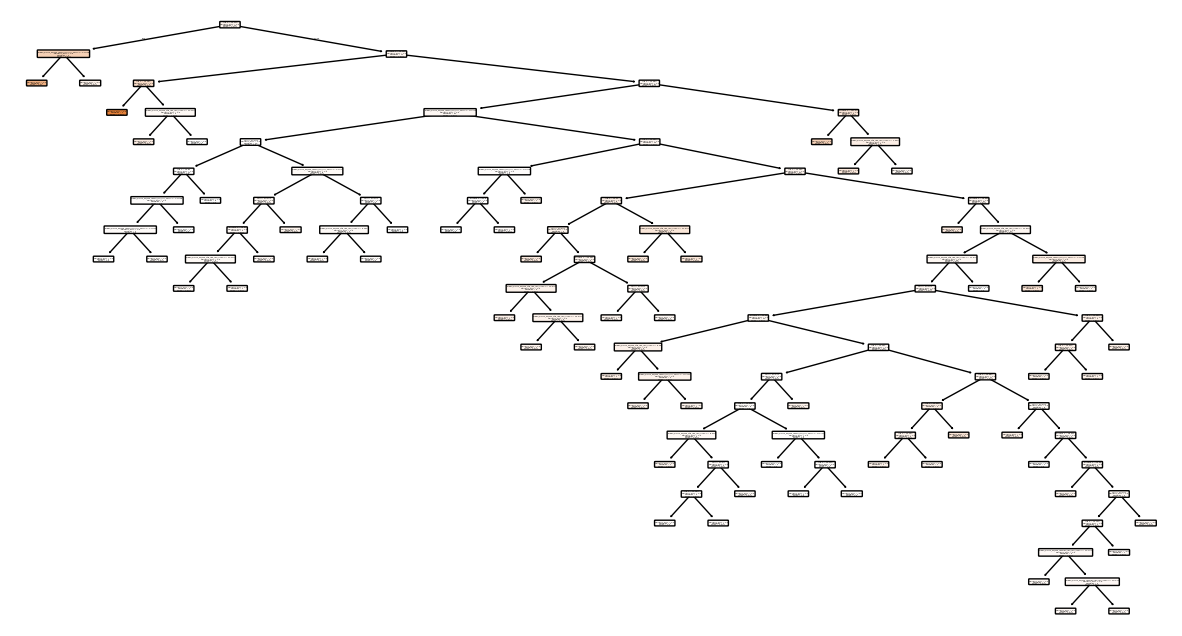

In [42]:
from sklearn.tree import plot_tree

# Visualizza l'albero
plt.figure(figsize=(15, 8))
plot_tree(tree, feature_names=x_train.columns, filled=True, rounded=True)
plt.show()


The number of nodes and consequently the number of sheets seems quite large.

In [43]:
num_nodes = tree.tree_.node_count
num_leaves = sum(tree.tree_.children_left == -1) # Crea un array booleano per contare quanti nodi non hanno figli sinistri e somma

print(f"Numero di nodi: {num_nodes}")
print(f"Numero di foglie: {num_leaves}")

Numero di nodi: 117
Numero di foglie: 59


The test data is insufficient to support such a large number of leaves, and the low quality of the results ($R^2$, MAE, RMSE) suggests a possibility of overfitting in the model trained on the train set. In this context, you should consider using a simpler tree, with fewer nodes. A promising approach in this case is Cost Complexity Pruning, which allows optimizing the complexity of the decision tree, avoiding over-fitting to the training data.
The most suitable $\alpha$ value was evaluated with cross validation (k=5) that minimized the Mean Squared Error (MSE). 

The CCP, unlike the max_deph limitation, optimizes the size of the tree with respect to the complexity parameter ($\alpha$) which balances the trade-off between bias (systematic error linked to impurity) and variance (error due to fluctuation linked to complexity).

To this end, it was considered appropriate to analyze the graph of the test/training error of the tree as the number of nodes varies with the iterated max_deph function and compare it with the CCP, and then evaluate its prediction robustness.

In [44]:
import plotly.graph_objects as go

# Funzione per calcolare errori e numero di nodi
def calculate_errors(depth_values, x_train, x_test, y_train, y_test):
    train_errors = []
    test_errors = []
    num_nodes = []
    
    for depth in depth_values: # Loop su tutti i valori di profondità
        model = DecisionTreeRegressor(max_depth=depth, random_state=42)
        model.fit(x_train, y_train)
        
        y_train_pred = model.predict(x_train)
        y_test_pred = model.predict(x_test)

        train_errors.append(mean_squared_error(y_train, y_train_pred))
        test_errors.append(mean_squared_error(y_test, y_test_pred))
        num_nodes.append(model.tree_.node_count)
    
    return train_errors, test_errors, num_nodes

depth_values = np.concatenate([np.arange(1, 6), np.arange(6, 21, 2)]) # Valori di profondità da 1 a 5 e da 6 a 20 con step 2 per maggiore dettaglio a basse profondità

# Calcolo errori e nodi
train_errors, test_errors, num_nodes = calculate_errors(depth_values, x_train, x_test, y_train, y_test)

# Inizializzazione un oggetto Figure (fig)
fig = go.Figure()

# Aggiunge a fig un grafico a dispersione per il train
fig.add_trace(go.Scatter(
    x=num_nodes, y=train_errors, mode='markers+lines',
    name="Training Error",
    marker=dict(color='blue', size=8),
    text=[f"Nodi: {n}" for n in num_nodes],  # Tooltip personalizzato
    hoverinfo="text+y" 
))

# Scatter per Test Error
fig.add_trace(go.Scatter(
    x=num_nodes, y=test_errors, mode='markers+lines',
    name="Test Error",
    marker=dict(color='red', size=8),
    text=[f"Nodi: {n}" for n in num_nodes],  # Tooltip personalizzato
    hoverinfo="text+y"
))

fig.update_layout(
    title="Training Error vs Test Error in funzione del Numero di Nodi",
    xaxis_title="Numero di Nodi",
    yaxis_title="Errore Medio Quadratico (MSE)",
    yaxis=dict(tickformat=".2e"), # Notazione scientifica per l'asse y
    template="plotly_white",
    hovermode="x unified" # Serve così che quando si passa sopra un punto si vedano entrambi i valori di errore
)

fig.show()

In [ ]:
full_tree = tree

train_errors_pruning = []
test_errors_pruning = []
num_nodes_pruning = []
alpha_used = []
alpha_scores = []


path = full_tree.cost_complexity_pruning_path(x_train, y_train) # Calcola il percorso di pruning
ccp_alphas = path.ccp_alphas #  Valori di alpha per il pruning

# Calcola l'errore per ogni alpha e lo aggiunge alla lista alpha_scores
for alpha in ccp_alphas:
    model = DecisionTreeRegressor(random_state=42, ccp_alpha=alpha)
    scores = cross_val_score(model, x_train, y_train, scoring="neg_mean_squared_error", cv=kf)
    alpha_scores.append((alpha, -np.mean(scores)))

# Trova il miglior alpha con il punteggio più basso di errore
best_alpha = min(alpha_scores, key=lambda x: x[1])[0] # lamda ordina i risulytati in base al secondo elemento della tupla e 0 estrae il corrispettivo alpha
print(f"Miglior alpha selezionato con CV: {best_alpha}")

# Costruzione degli alberi con diversi alpha, incluso quello migliore
alpha_values = np.concatenate([np.linspace(0.0, 0.05, 10), ccp_alphas])

for alpha in alpha_values:
    pruned_tree = DecisionTreeRegressor(random_state=42, ccp_alpha=alpha)
    pruned_tree.fit(x_train, y_train)

    y_train_pred = pruned_tree.predict(x_train)
    y_test_pred = pruned_tree.predict(x_test)

    train_errors_pruning.append(mean_squared_error(y_train, y_train_pred))
    test_errors_pruning.append(mean_squared_error(y_test, y_test_pred))

    num_nodes_pruning.append(pruned_tree.tree_.node_count)
    alpha_used.append(alpha)  # Salva l'alpha corrispondente

# Ordina i risultati in base al numero di nodi
sorted_ind = np.argsort(num_nodes_pruning)
num_nodes_pruning = np.array(num_nodes_pruning)[sorted_ind]
train_errors_pruning = np.array(train_errors_pruning)[sorted_ind]
test_errors_pruning = np.array(test_errors_pruning)[sorted_ind]
alpha_used = np.array(alpha_used)[sorted_ind] 

# Creazione della figura con Plotly
fig1 = go.Figure()

fig1.add_trace(go.Scatter(
    x=num_nodes_pruning, y=train_errors_pruning, mode='markers+lines',
    name="Training Error",
    marker=dict(color='blue', size=8),
    text=[f"Nodi: {n}<br>Alpha: {a:.1e}" for n, a in zip(num_nodes_pruning, alpha_used)], # zip unisce due liste in una tupla (nodi, alpha)
    hoverinfo="text+y"
))

fig1.add_trace(go.Scatter(
    x=num_nodes_pruning, y=test_errors_pruning, mode='markers+lines',
    name="Test Error",
    marker=dict(color='red', size=8),
    text=[f"Nodi: {n}<br>Alpha: {a:.1e}" for n, a in zip(num_nodes_pruning, alpha_used)],
    hoverinfo="text+y"
))

fig1.update_layout(
    title="Training Error vs Test Error con Cost Complexity Pruning (CCP)",
    xaxis_title="Numero di Nodi dopo il pruning",
    yaxis_title="Errore Medio Quadratico (MSE)",
    yaxis=dict(tickformat=".2e"),
    template="plotly_white",
    hovermode="x unified"
)

fig1.show()


Miglior alpha selezionato con CV: 1.1590435719785408e-06


Comparing the two test/training error graphs we note that the minimum for the test error is for the first 7-node graph. For the second (CCP) it results in 1 node.

For a matter of triviality it is necessary to complicate the model since a tree with a node (a decision) does not make sense in the context under consideration. The number of nodes to create the tree with the CCP method is between 7, 9 and 11.
In this case we chose to compare the minimum of the first graph and the second (excluding 1).

Trovato alpha per 7 nodi: 4.6760700767274177e-07
Trovato alpha per 9 nodi: 1.970434179194528e-07


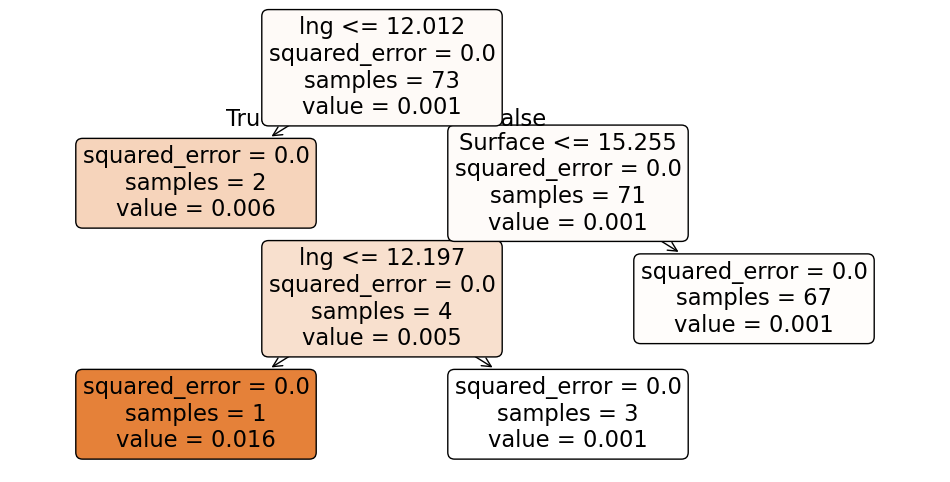

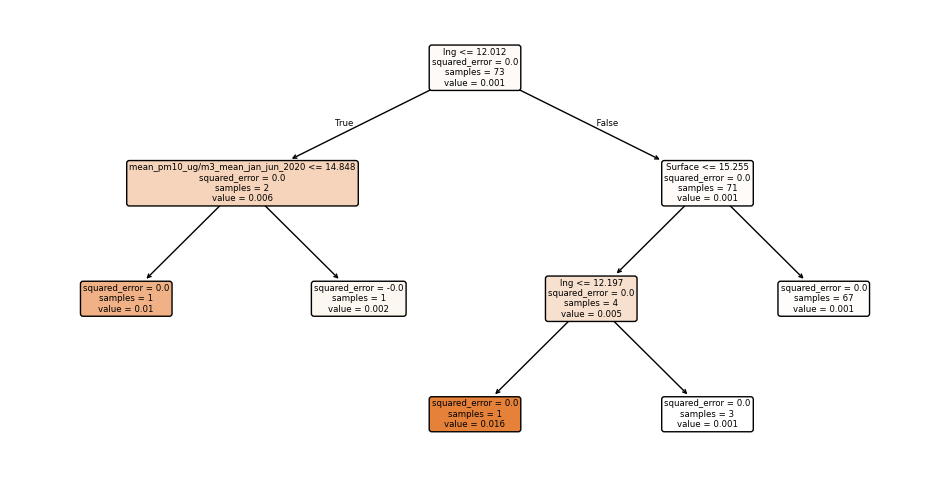

Performance per l'albero con 7 nodi: 
R²: -0.1492
RMSE: 0.0060
MAE: 0.0026
Performance per l'albero con 9 nodi: 
R²: -0.1344
RMSE: 0.0060
MAE: 0.0025


In [46]:
def train_tree_with_n_nodes(target_nodes, x_train, y_train, ccp_alphas):
    
    # Crea un albero decisionale con esattamente `target_nodes` nodi.
    # Restituisce l'albero addestrato e il valore di alpha utilizzato.
    
    # Ordina gli alpha in ordine decrescente per trovare più rapidamente l'albero desiderato
    sorted_ccp_alphas = sorted(ccp_alphas, reverse=True)

    # Inizializza l'alpha più alto per partire con un albero molto potato
    best_alpha = sorted_ccp_alphas[0]  

    for alpha in sorted_ccp_alphas:
        pruned_tree = DecisionTreeRegressor(random_state=42, ccp_alpha=alpha)
        pruned_tree.fit(x_train, y_train)

         # Se l'albero ha esattamente il numero di nodi richiesto, ci fermiamo
        if pruned_tree.tree_.node_count == target_nodes:
            best_alpha = alpha  # Memorizza l'alpha che dà il numero di nodi desiderato
            print(f"Trovato alpha per {target_nodes} nodi: {best_alpha}")
            break

    # Creazione del modello finale con l'alpha trovato
    final_tree = DecisionTreeRegressor(random_state=42, ccp_alpha=best_alpha)
    final_tree.fit(x_train, y_train)

    return final_tree, best_alpha

def evaluate_model(model, x_train, y_train, x_test, y_test):
    # Calcola R², RMSE e MAE per il modello
    y_train_pred = model.predict(x_train)
    y_test_pred = model.predict(x_test)

    r2 = r2_score(y_test, y_test_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    mae = mean_absolute_error(y_test, y_test_pred)

    print(f"R²: {r2:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE: {mae:.4f}")
# Non restituisce nulla poiché stampa i risultati autonomamente
    

# Trova gli alberi con numero di nodi desiderato (7,9) nel nostro caso
tree_7, alpha_7 = train_tree_with_n_nodes(7, x_train, y_train, ccp_alphas)
tree_9, alpha_9 = train_tree_with_n_nodes(9, x_train, y_train, ccp_alphas)

plt.figure(figsize=(12, 6))
plt.title(f"Albero con 7 nodi (alpha={alpha_7:.5f})")
plot_tree(tree_7, filled=True, feature_names=x_train.columns, rounded=True)
plt.show()

plt.figure(figsize=(12, 6))
plt.title(f"Albero con 9 nodi (alpha={alpha_9:.5f})")
plot_tree(tree_9, filled=True, feature_names=x_train.columns, rounded=True)
plt.show()

# Valutazione delle performance
print("Performance per l'albero con 7 nodi: ")
evaluate_model(tree_7, x_train, y_train, x_test, y_test)

print("Performance per l'albero con 9 nodi: ")
evaluate_model(tree_9, x_train, y_train, x_test, y_test)


Thanks to the results of the evaluation metrics it is possible to state that the two trees simplified with the CCP method do not differ much in accuracy. 

At this point, given the poor predictive ability, the choice is made on the basis of readability; which leads to the final model described by a 7-node tree (built with the CCP method).

Thanks to this study the tree has been reduced in complexity and is now readable.
We see that the most discriminating features are:
- Longitude;
- Surface.

This suggests that fine dust pollution data may not be influential on the number of covid cases normalized to the population. Definitely not in the case of a single decision tree.

Let's remember the values previously found:
- R²: -0.2556
- RMSE: 0.0063
- MAE: 0.0030

The tree model trained with the training data and subsequently simplified with the CCP method actually shows better results, although only slightly.

In fact, the improvement given by the latest analysis is almost irrelevant.

It is not possible to know with certainty whether there could actually be a connection between pollution/geographical data and epidemiological data. What emerges, to conclude, is that neither a model based on linear regression nor a tree-based model with CCP succeeds in building a satisfactory regression model.

### Considerations on outliers:

As a final task, it was deemed useful to deepen the analysis of the outlier data: Jupiter and Poran.

Several clues have raised doubts about the presence of anomalies in these municipalities: the number of Covid cases per thousand inhabitants is extremely high, especially considering the limited social activity that these localities should have had during the lockdown.

The investigation compares the maximum number of intensive care units, deaths and Covid cases, with the aim of verifying whether, as hypothesized, there is a connection between these factors. The analysis aimed to investigate whether the data suggests that the infection outbreaks originated within facilities for the elderly, such as retirement homes\RSAs. If so, the data will differ significantly from the values ​​observed in the other municipalities.

In [47]:
scatter_3d_plot_1 = build_3d_scatter_plot(
    df=cvdata_cleaned, 
    x_col='CovidCases_jan_jun_2020',  
    y_col='Deceased_jan_jun_2020',  
    z_col='MaxIntensiveCare_jan_jun_2020', 
    cluster_col='Zone',  
    hover_col='City',  
    title='3D Scatter Plot Outliers'
)
scatter_3d_plot_1()

The data, as expected, differs markedly from the behavior of others.
This strengthens the hypothesis introduced.